In [1]:
import os
import json
from graphviz import Digraph
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
def parse_logic_to_tree(logic, graph, parent=None, node_id=0):
    if 'raw_text' in logic:
        node_label = logic['raw_text']
        graph.node(str(node_id), label=node_label, shape='box')
        if parent is not None:
            graph.edge(parent, str(node_id))
        return node_id

    for key in logic:
        if key in ('AND', 'OR', 'NOT'):
            operator = key
            node_label = operator
            current_node_id = node_id
            color = 'lightblue' if operator == 'AND' else 'lightgreen' if operator == 'OR' else 'lightcoral'
            graph.node(str(current_node_id), label=node_label, color=color, fontcolor='black', style='filled', fillcolor=color)
            if parent is not None:
                graph.edge(parent, str(current_node_id))

            operands = logic[key]
            node_id += 1
            if 'left' in operands:
                left_id = parse_logic_to_tree(operands['left'], graph, str(current_node_id), node_id)
                node_id = left_id + 1
            if 'right' in operands:
                right_id = parse_logic_to_tree(operands['right'], graph, str(current_node_id), node_id)
                node_id = right_id + 1
            if operator == 'NOT':
                node_id += 1
    return node_id

def visualize_logic_tree(logic):
    graph = Digraph(format='png')
    parse_logic_to_tree(logic, graph)
    return graph

def plot_and_save_graph(logic, graph_title, output_filename):
    graph = visualize_logic_tree(logic)
    graph.render(filename='temp', view=False, cleanup=True)
    image = Image.open('temp.png')
    plt.figure(figsize=(20, 15))
    plt.imshow(image)
    plt.axis('off')
    plt.title(graph_title)
    plt.savefig(output_filename)
    #plt.close()
    plt.show()

In [3]:
model_name = "Llama-3-8B-Instruct_4_shot"
n_shot = "25"
p2_label_path = "../chia_label/p2"
model_input_path = f"../model_output/{model_name}/ready"

picture_path = "batch1/tree_pictures"

n = 100

In [4]:
if not os.path.exists(picture_path):
    os.makedirs(picture_path)

label_files = [f for f in os.listdir(p2_label_path) if f.endswith("_parsed_2.json")][:n]
model_files = [f for f in os.listdir(model_input_path) if f.endswith(".json")][:n]

model_files

['Llama-3-8B-Instruct_NCT01236417_inc_4_shot.json',
 'Llama-3-8B-Instruct_NCT01261832_exc_4_shot.json',
 'Llama-3-8B-Instruct_NCT01261832_inc_4_shot.json',
 'Llama-3-8B-Instruct_NCT01312012_exc_4_shot.json',
 'Llama-3-8B-Instruct_NCT01312012_inc_4_shot.json',
 'Llama-3-8B-Instruct_NCT01313676_inc_4_shot.json',
 'Llama-3-8B-Instruct_NCT01314898_exc_4_shot.json',
 'Llama-3-8B-Instruct_NCT01314898_inc_4_shot.json',
 'Llama-3-8B-Instruct_NCT01320579_exc_4_shot.json',
 'Llama-3-8B-Instruct_NCT01320579_inc_4_shot.json',
 'Llama-3-8B-Instruct_NCT01322464_exc_4_shot.json',
 'Llama-3-8B-Instruct_NCT01346436_exc_4_shot.json',
 'Llama-3-8B-Instruct_NCT01346436_inc_4_shot.json',
 'Llama-3-8B-Instruct_NCT01349413_inc_4_shot.json',
 'Llama-3-8B-Instruct_NCT01352598_inc_4_shot.json',
 'Llama-3-8B-Instruct_NCT01373684_exc_4_shot.json',
 'Llama-3-8B-Instruct_NCT01373684_inc_4_shot.json',
 'Llama-3-8B-Instruct_NCT01391780_exc_4_shot.json',
 'Llama-3-8B-Instruct_NCT01391780_inc_4_shot.json',
 'Llama-3-8B

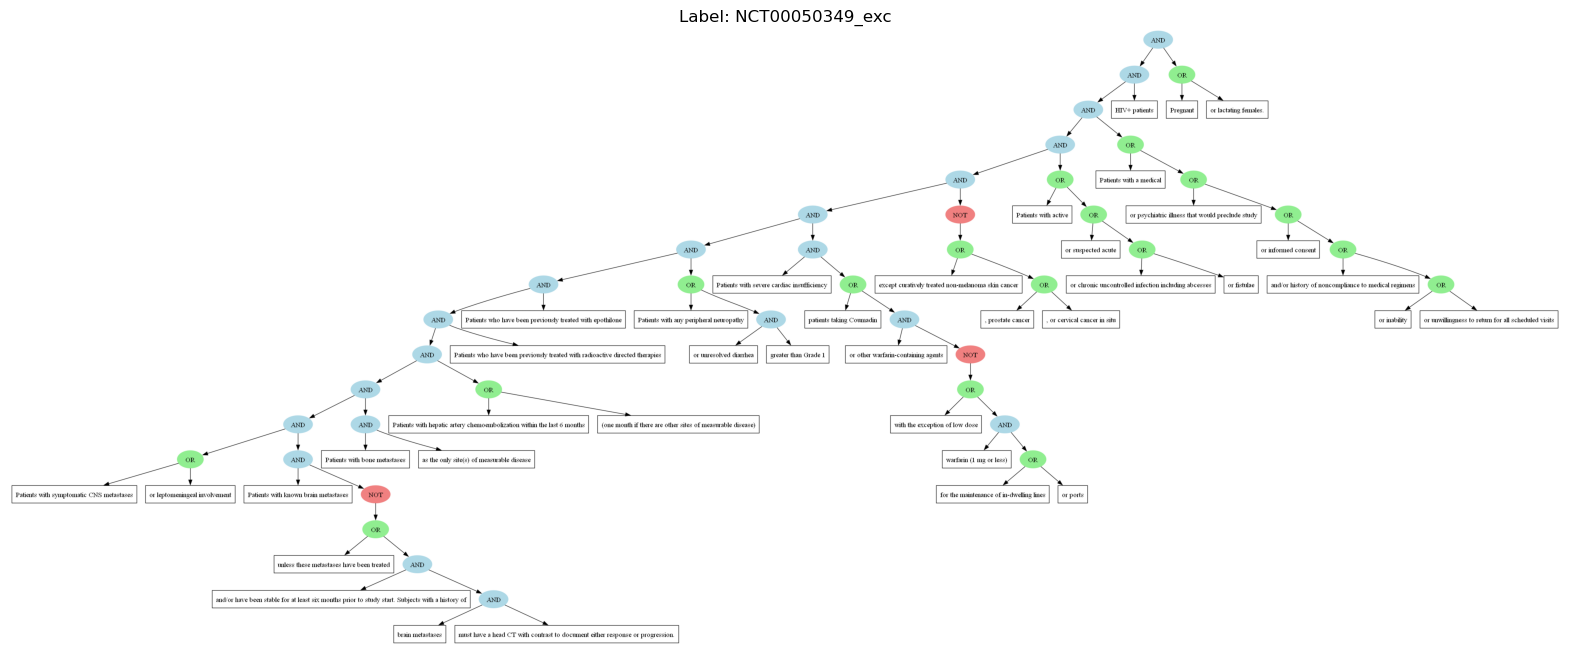

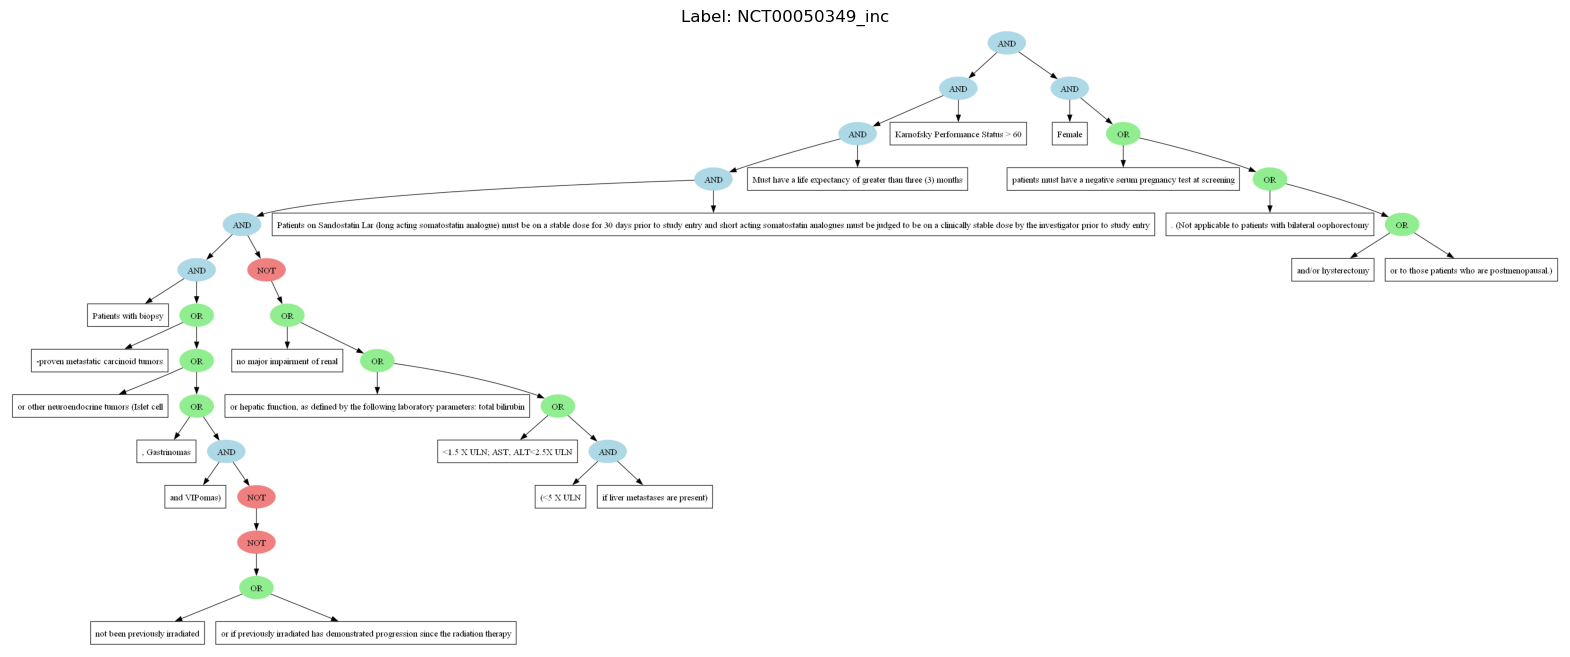

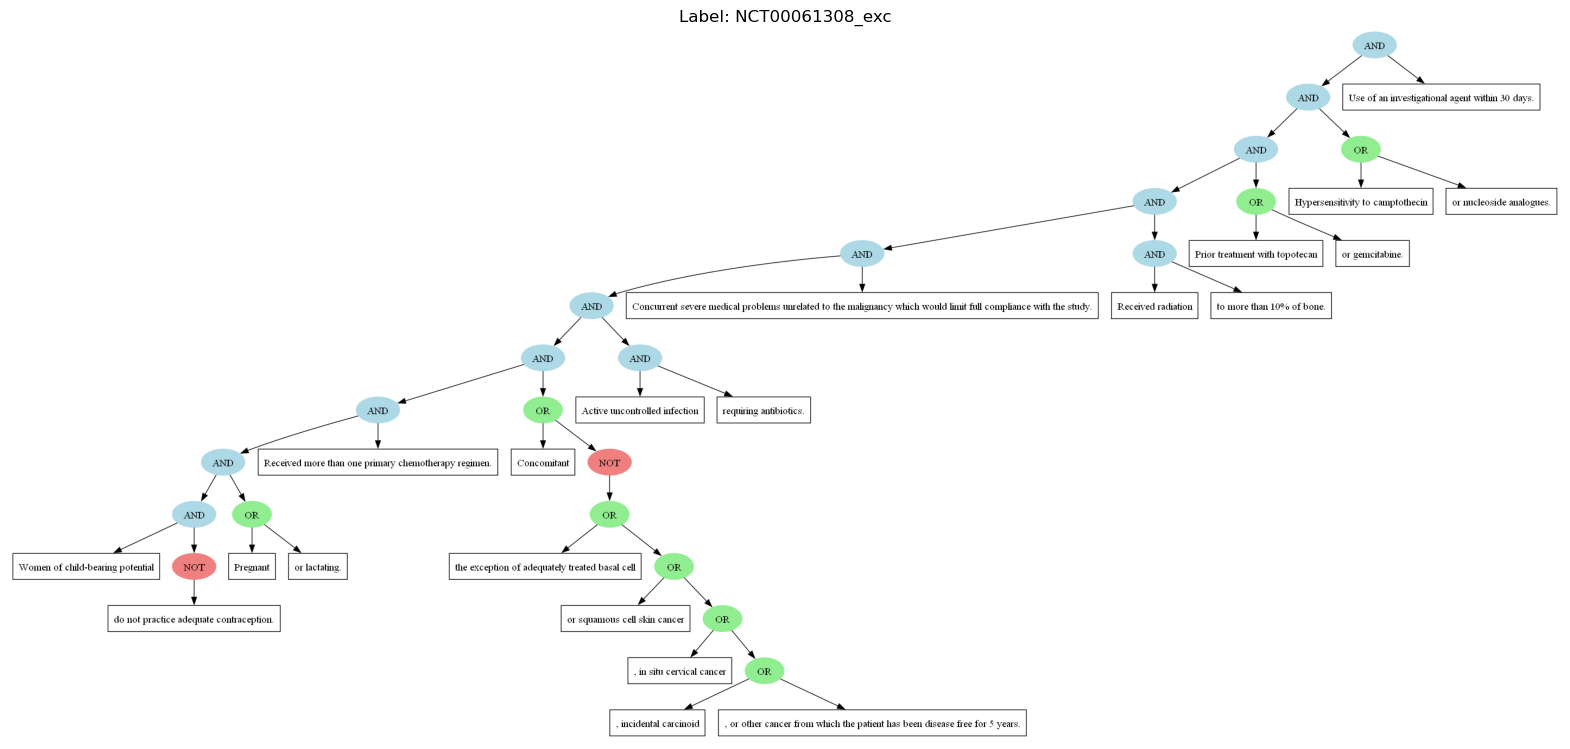

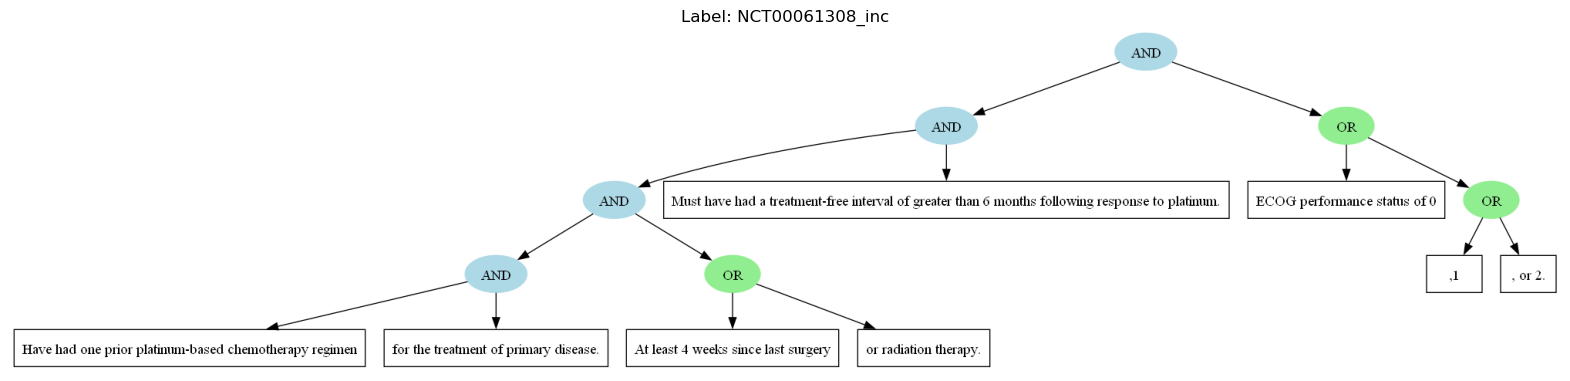

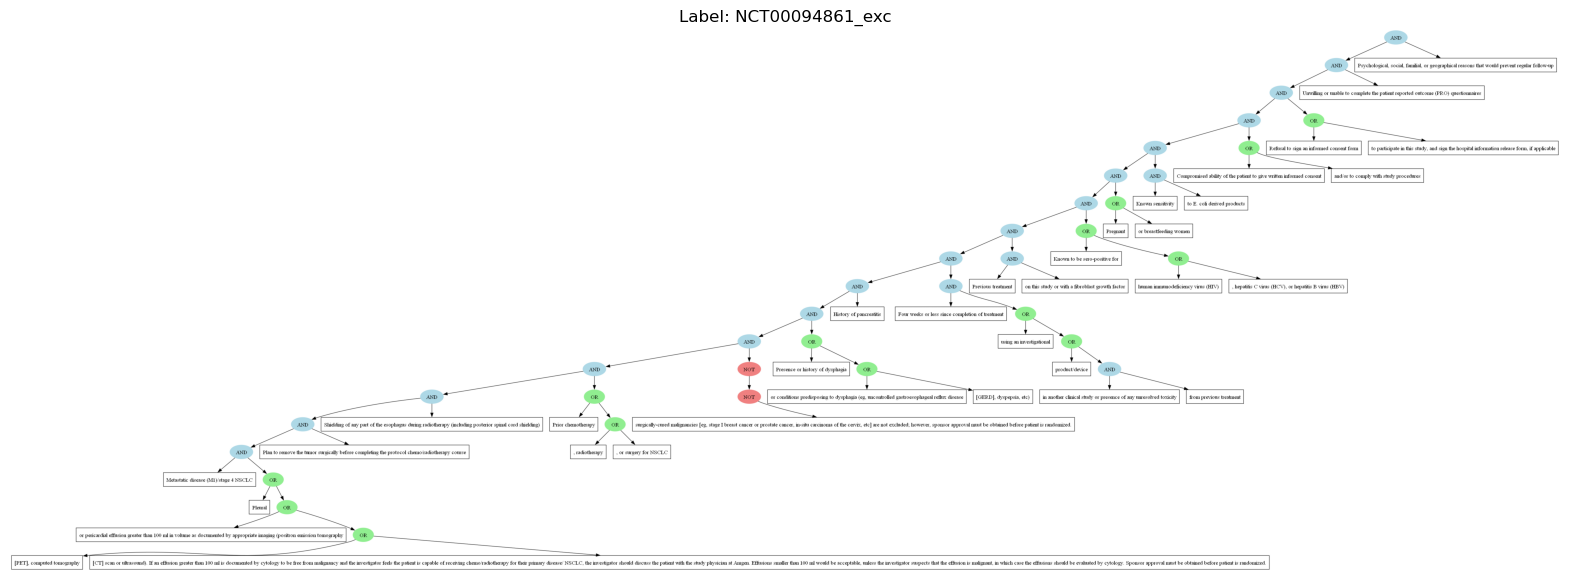

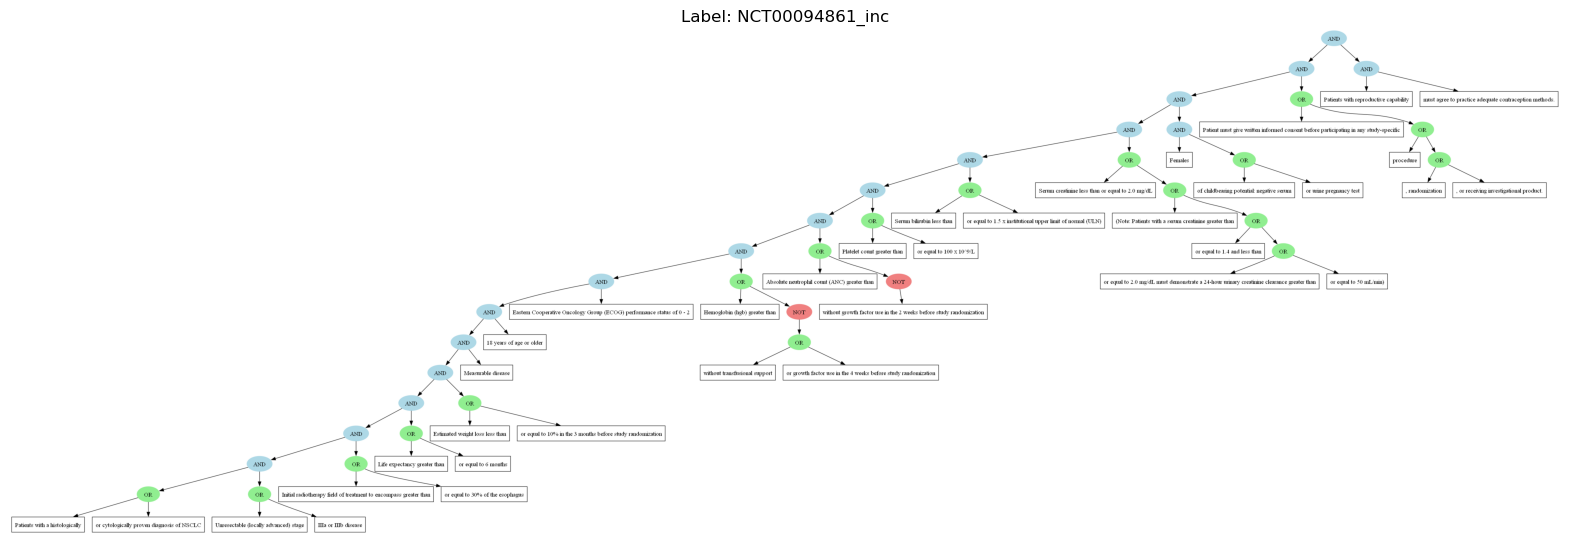

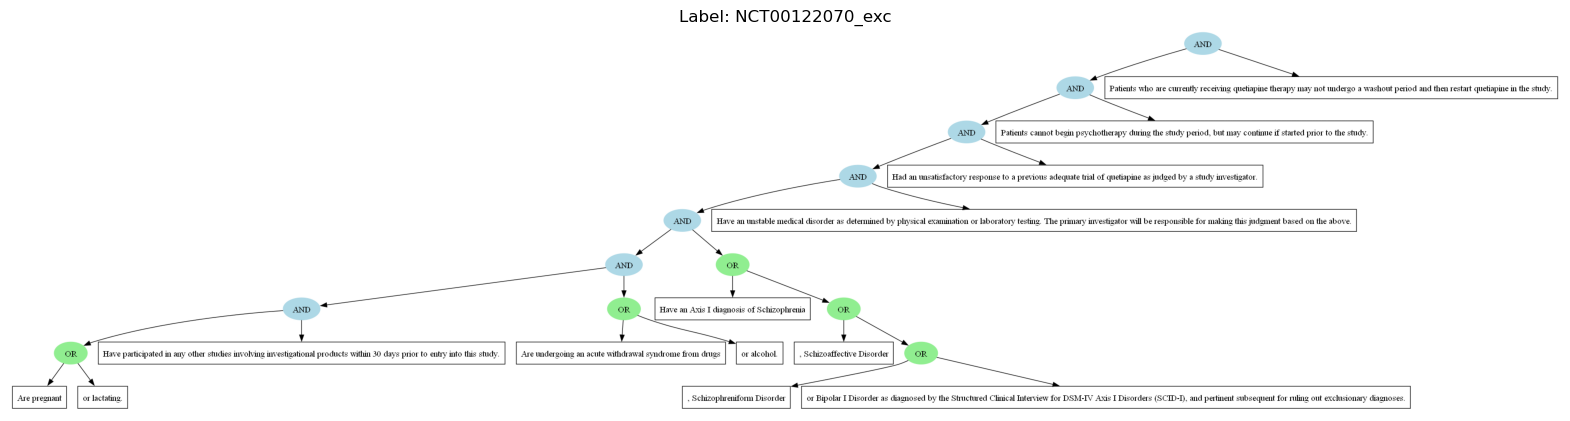

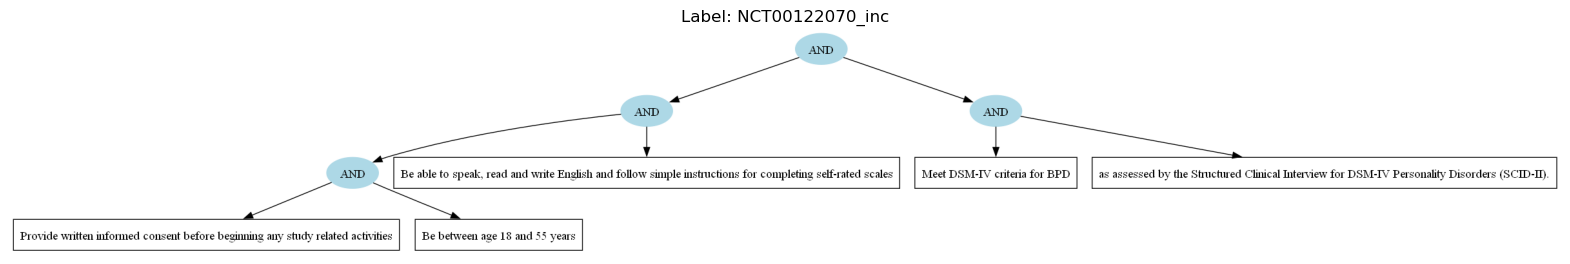

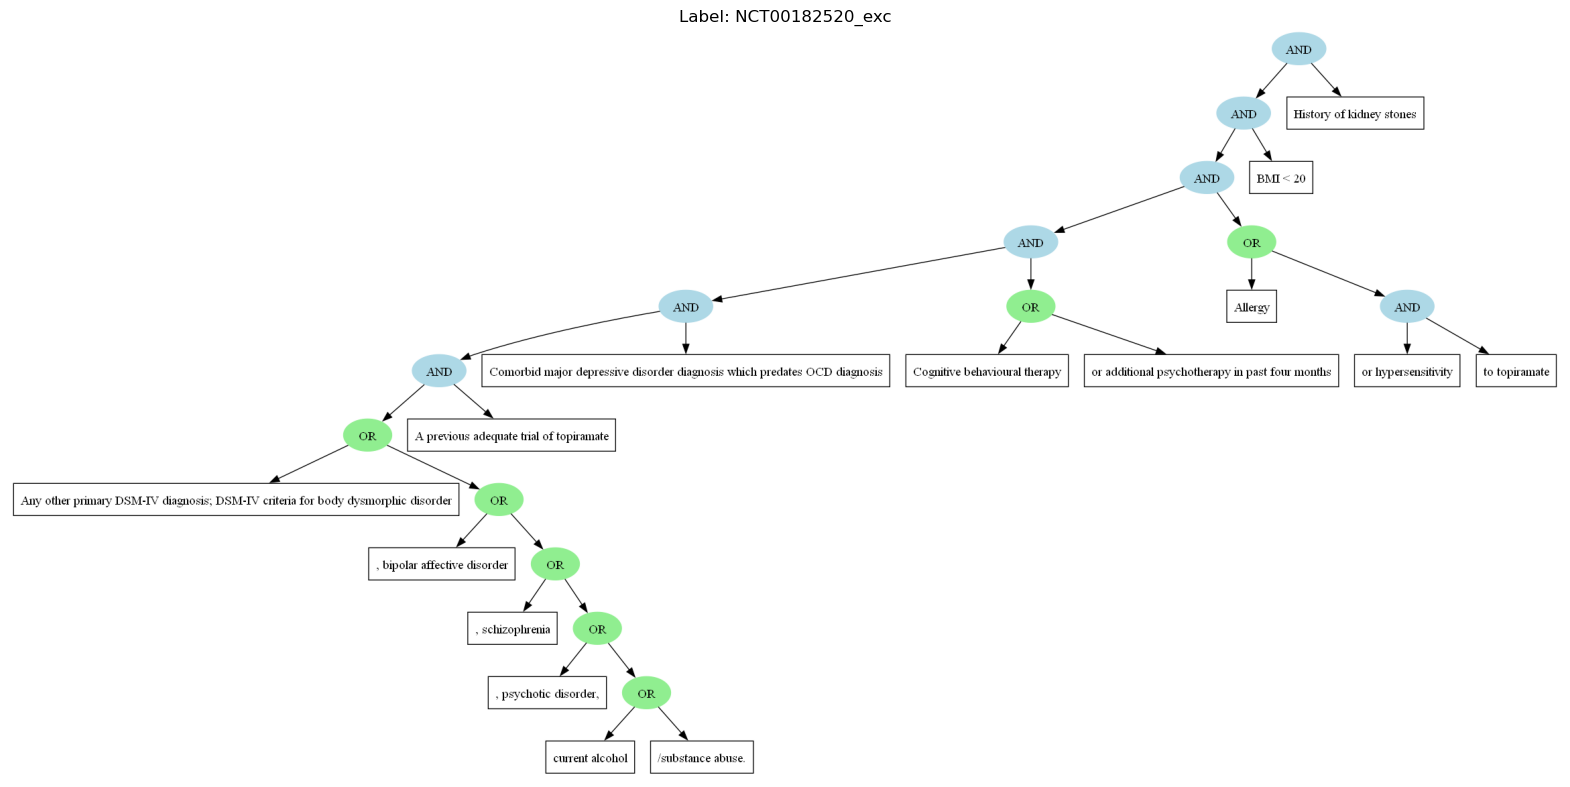

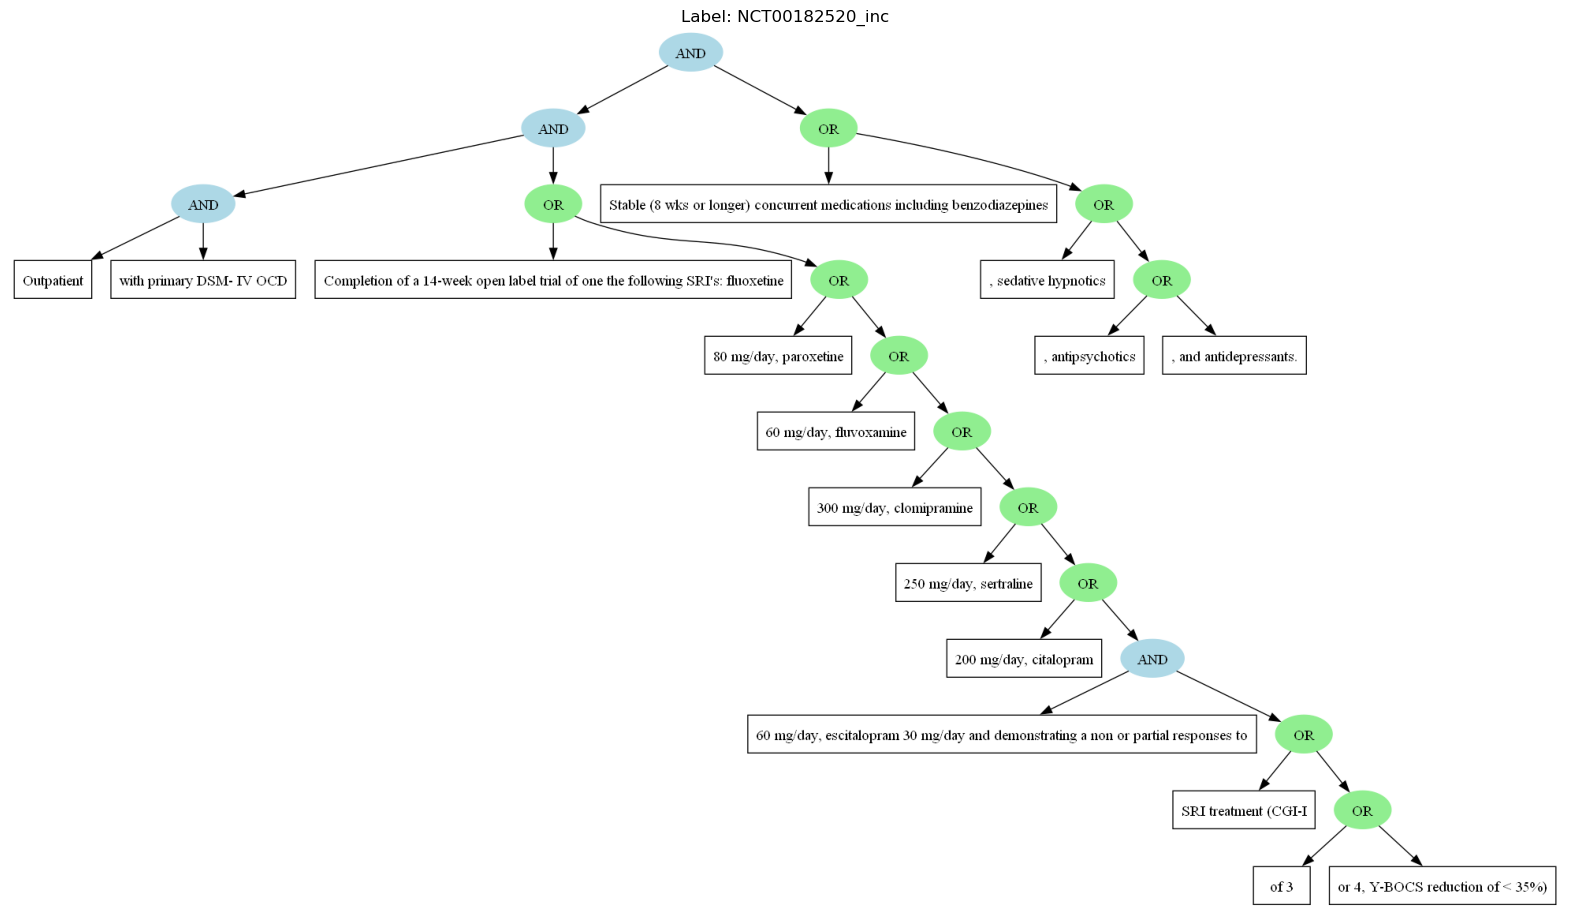

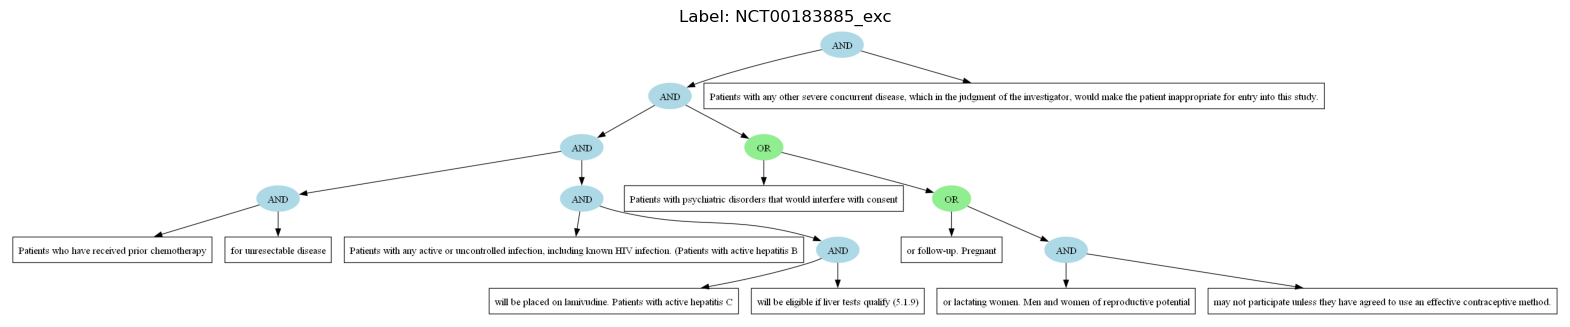

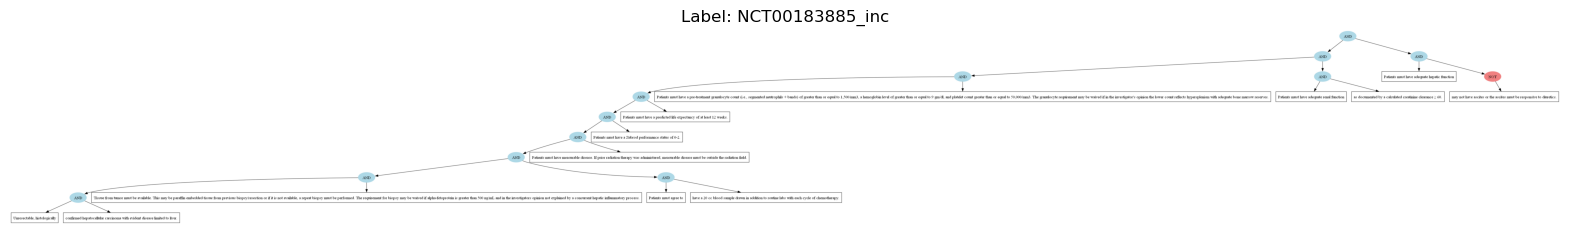

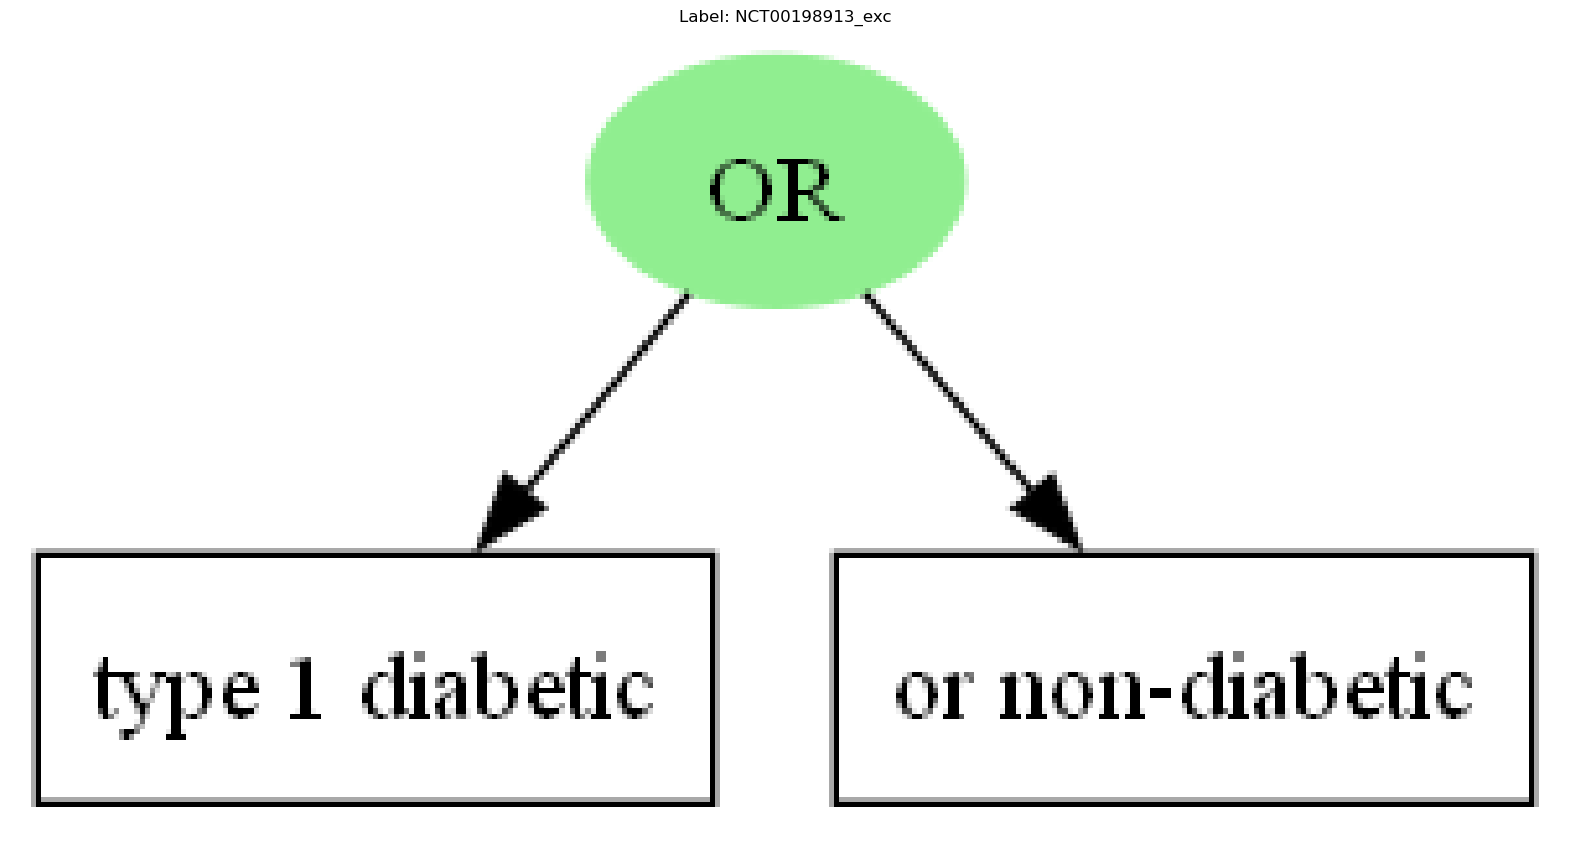

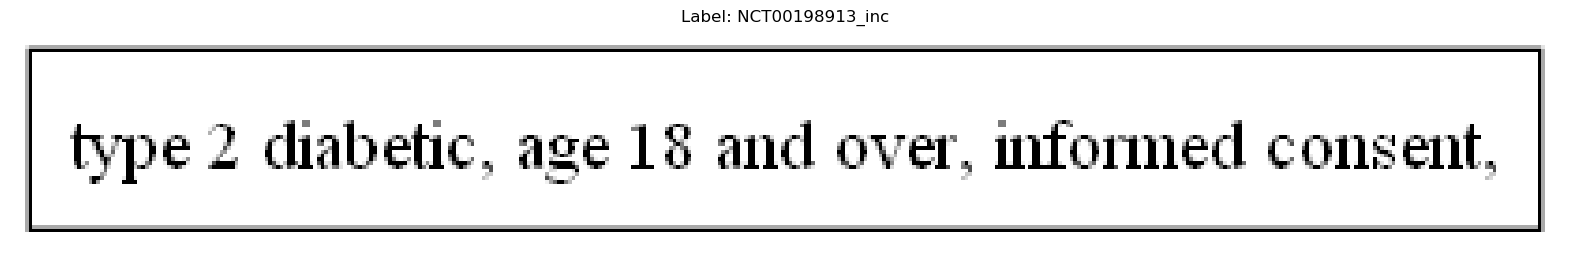

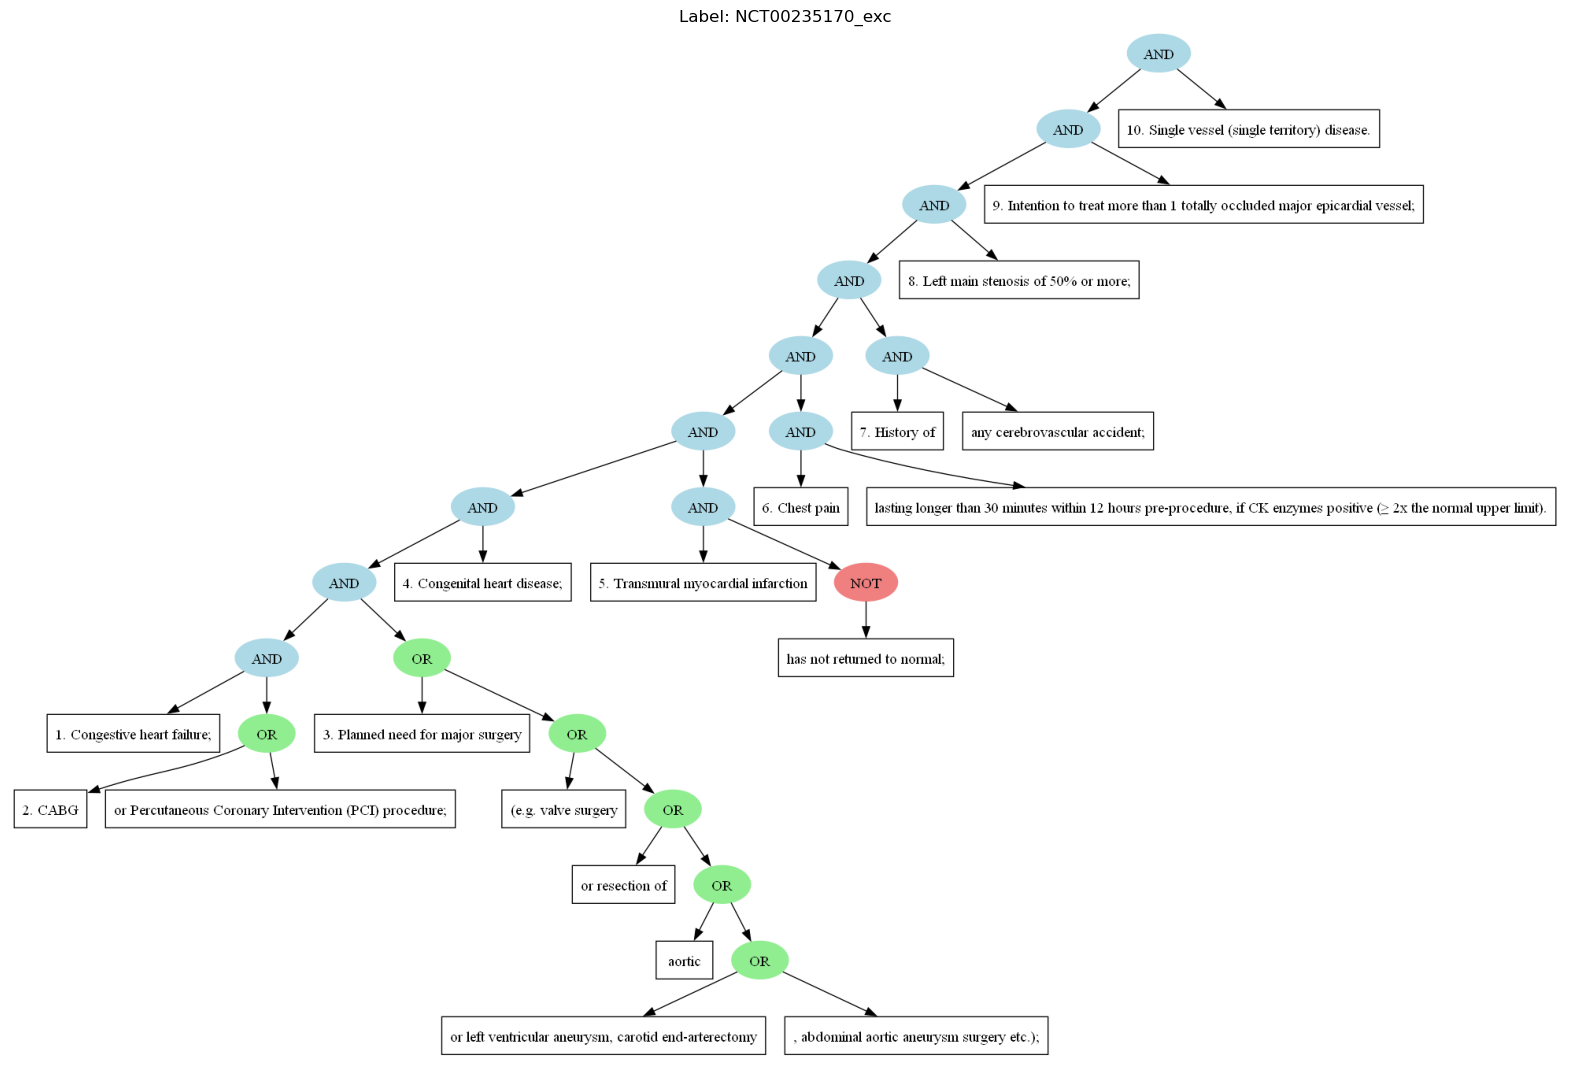

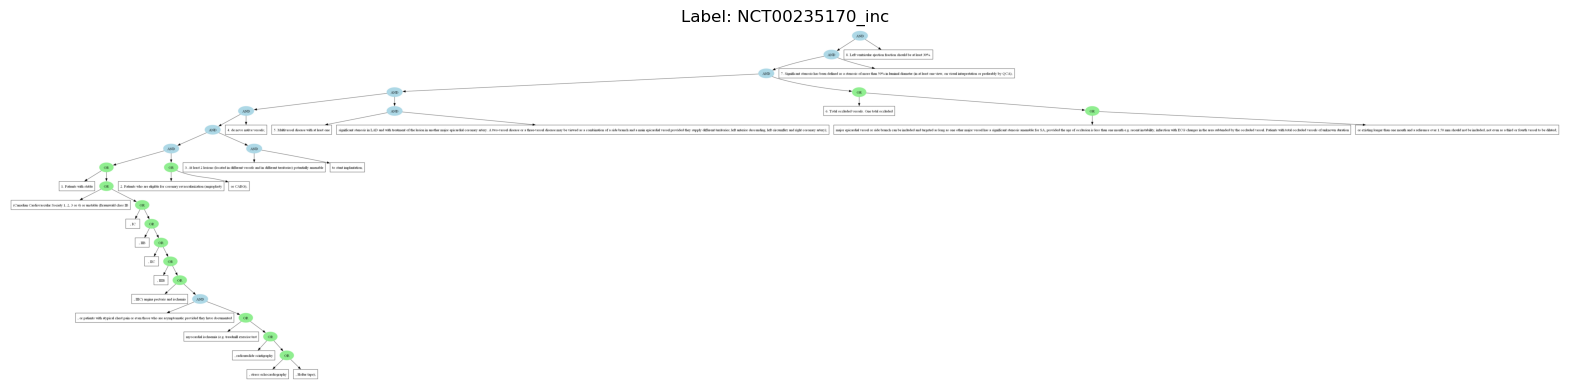

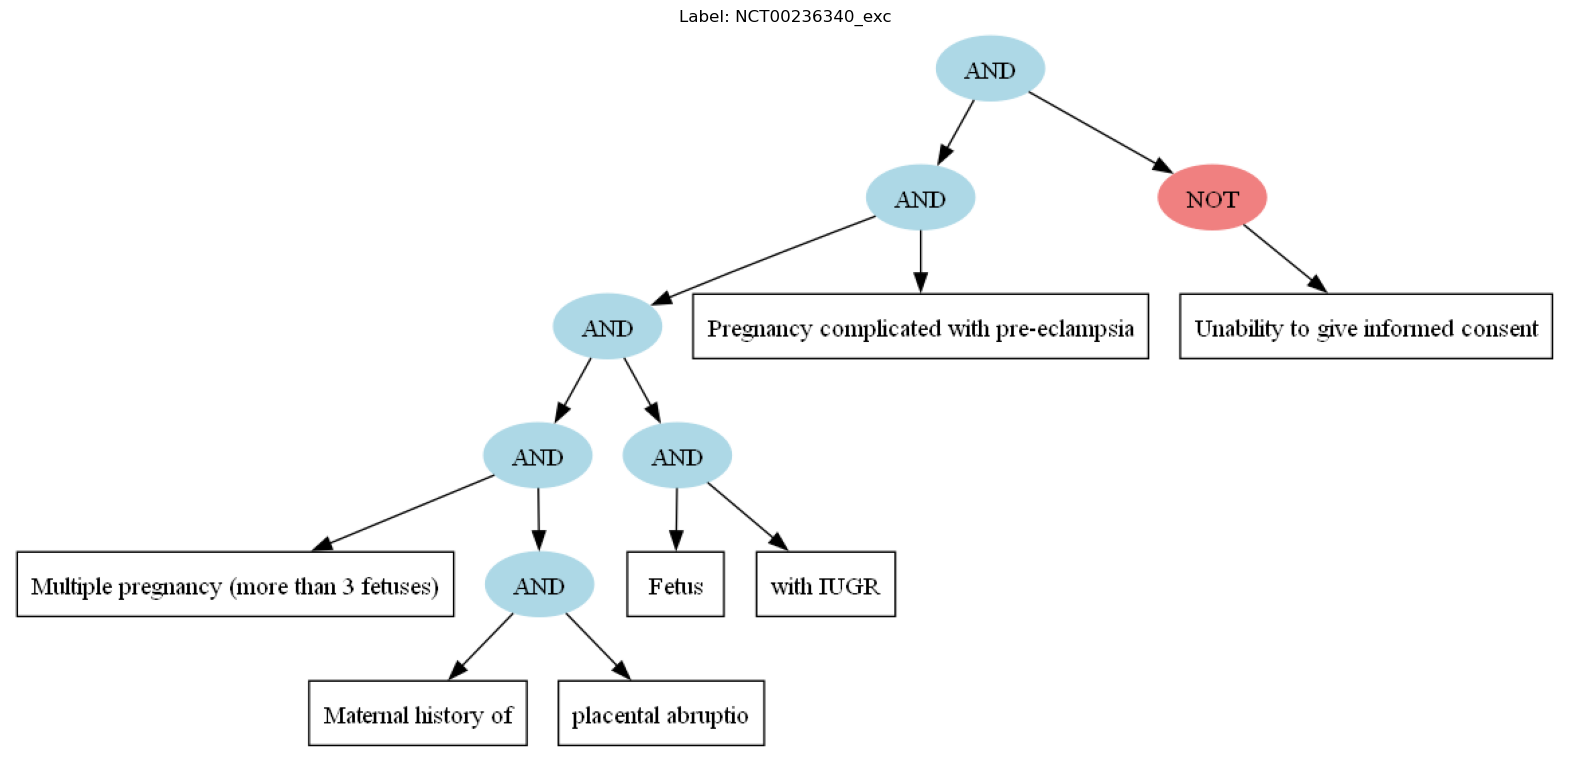

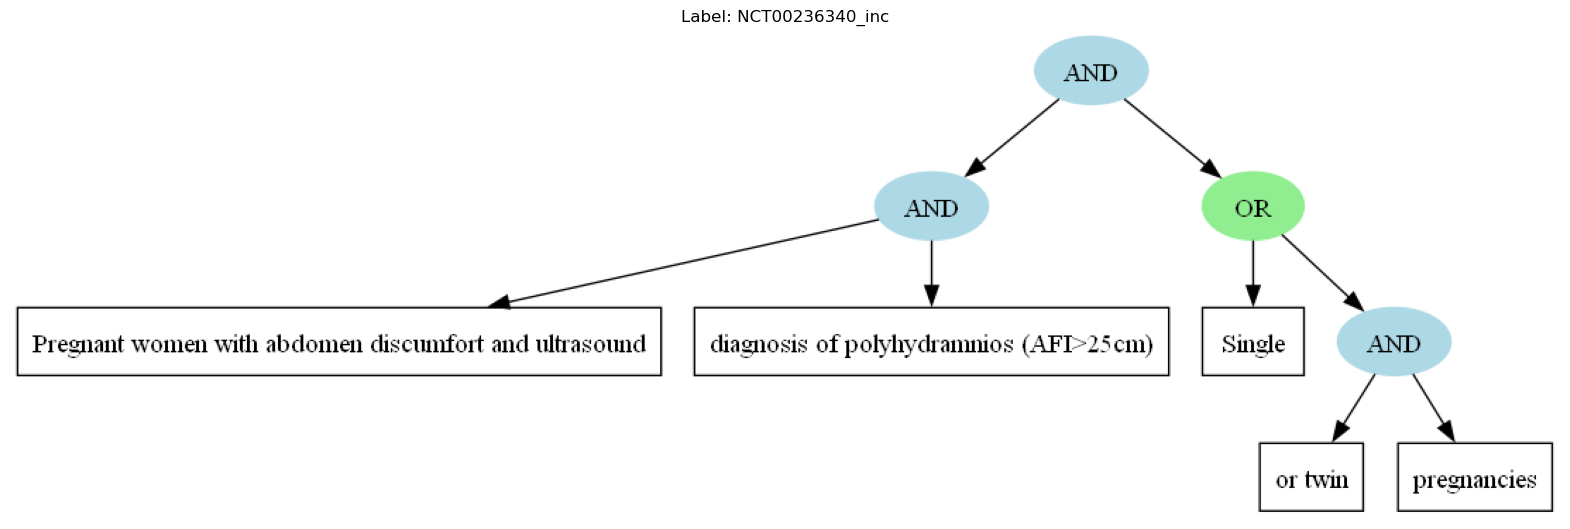

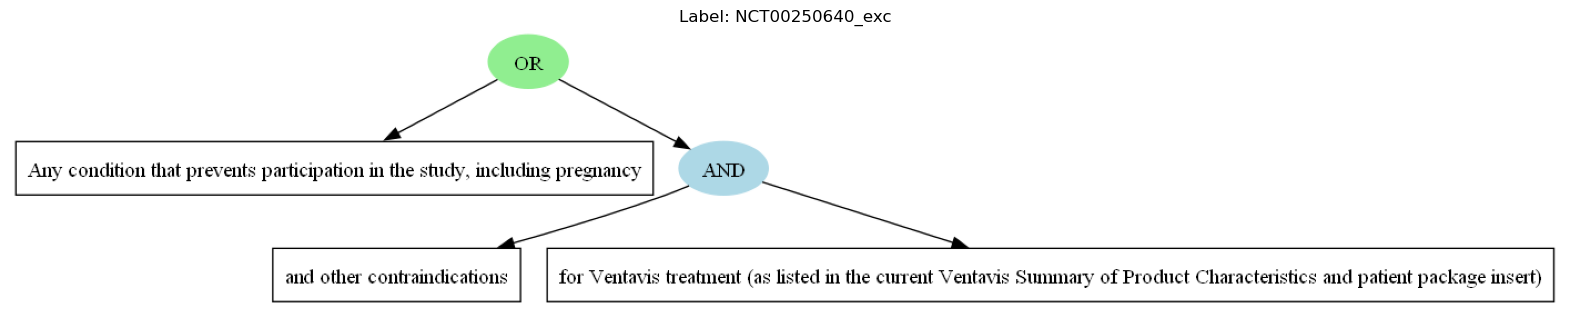

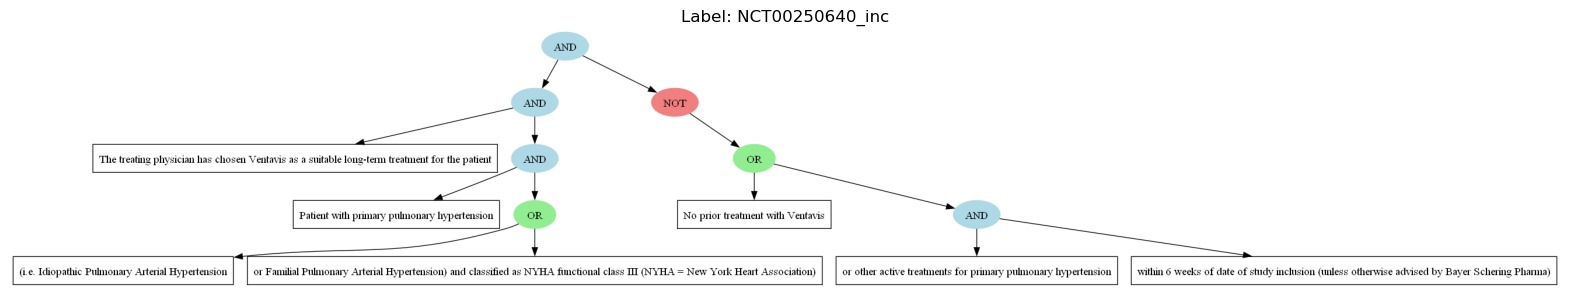

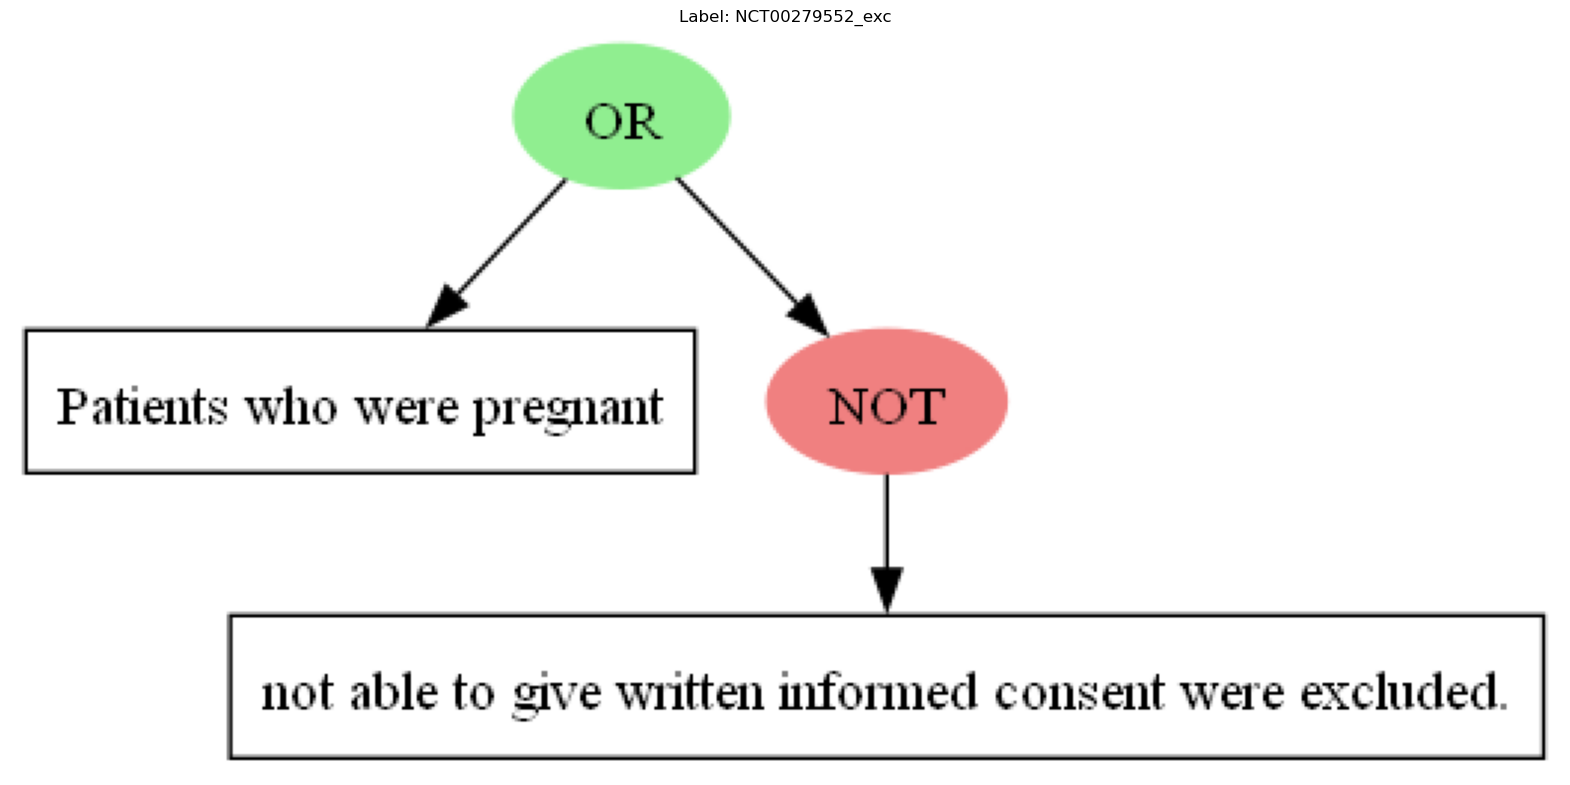

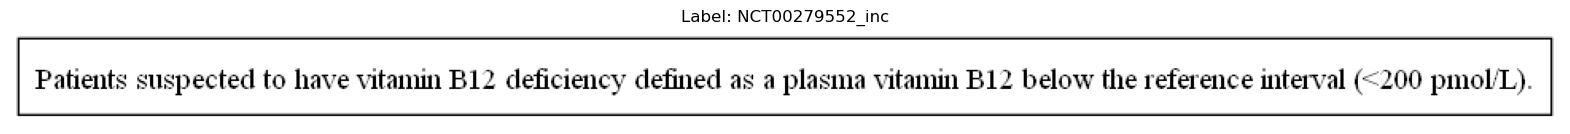

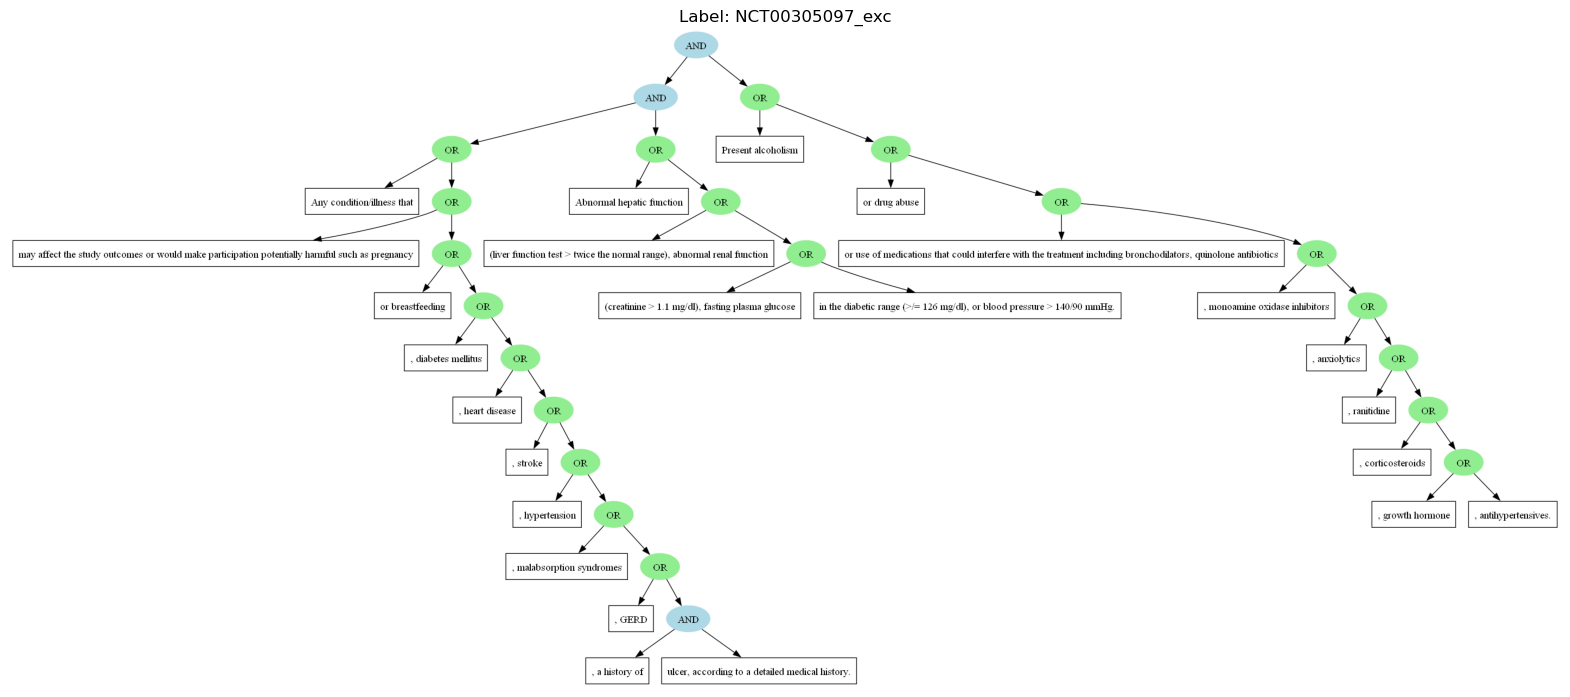

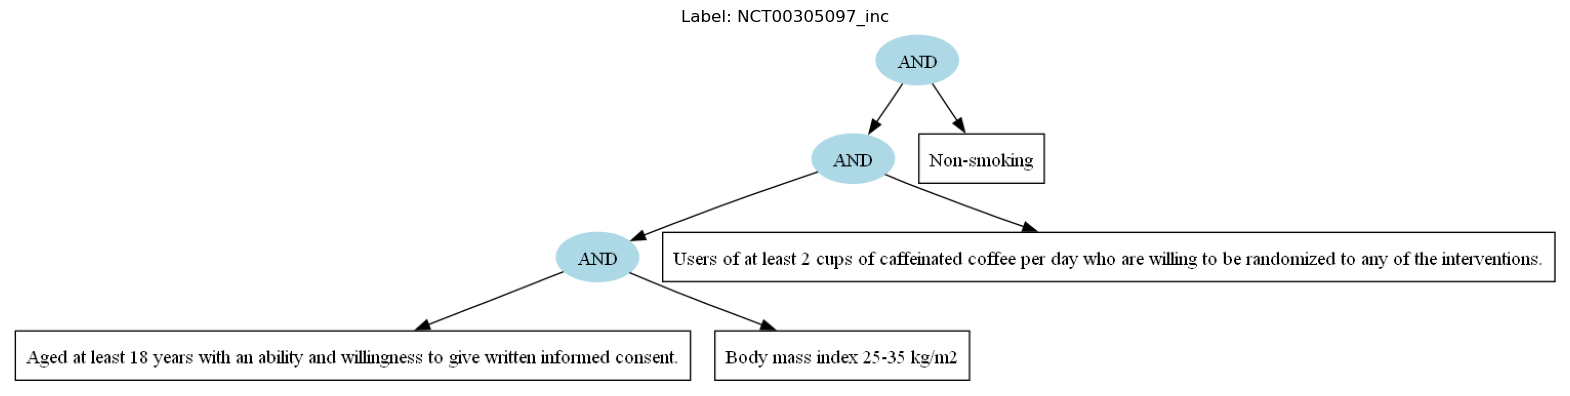

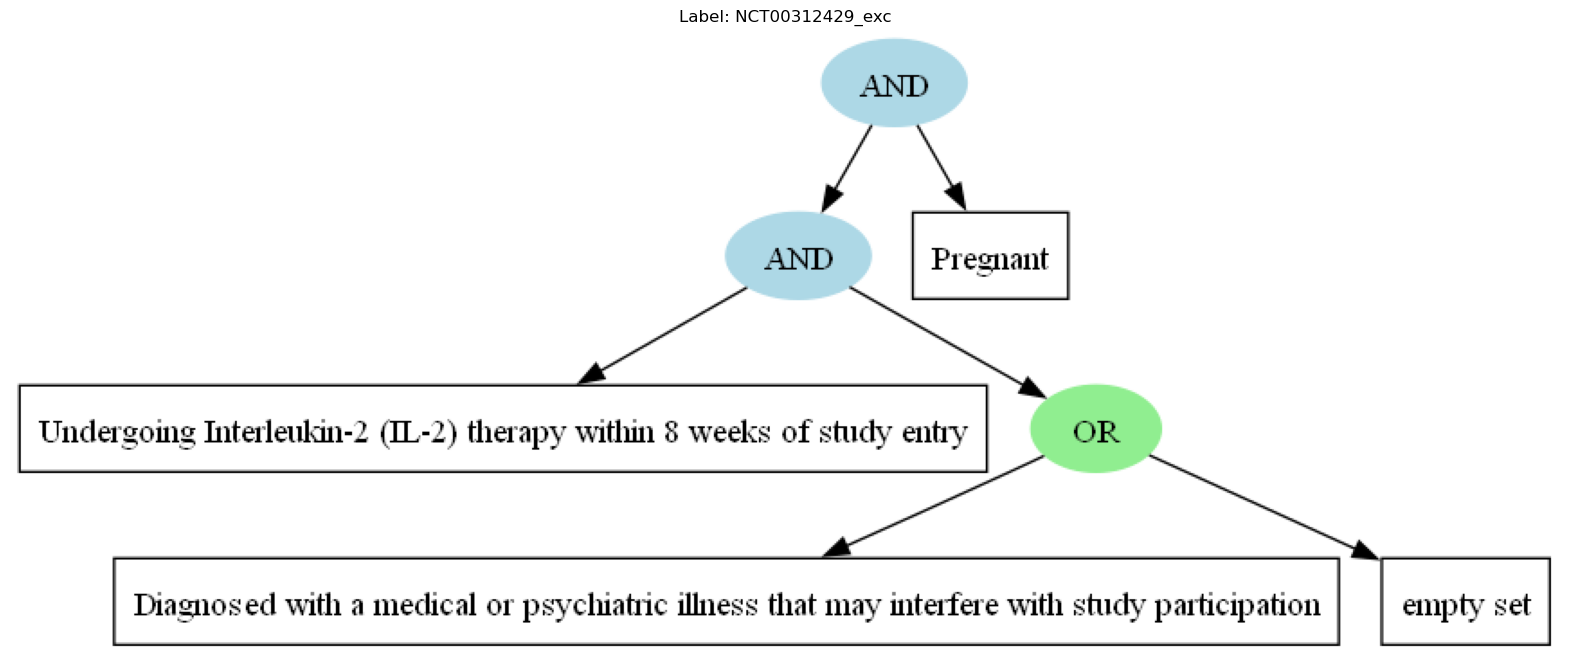

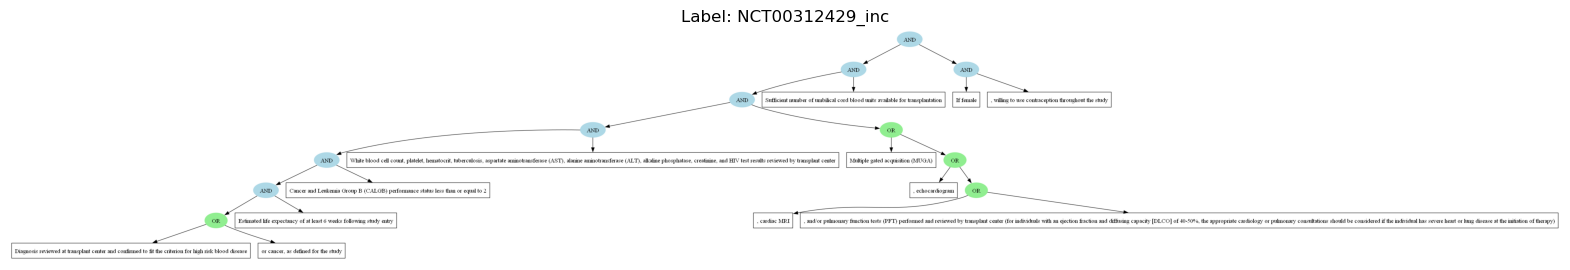

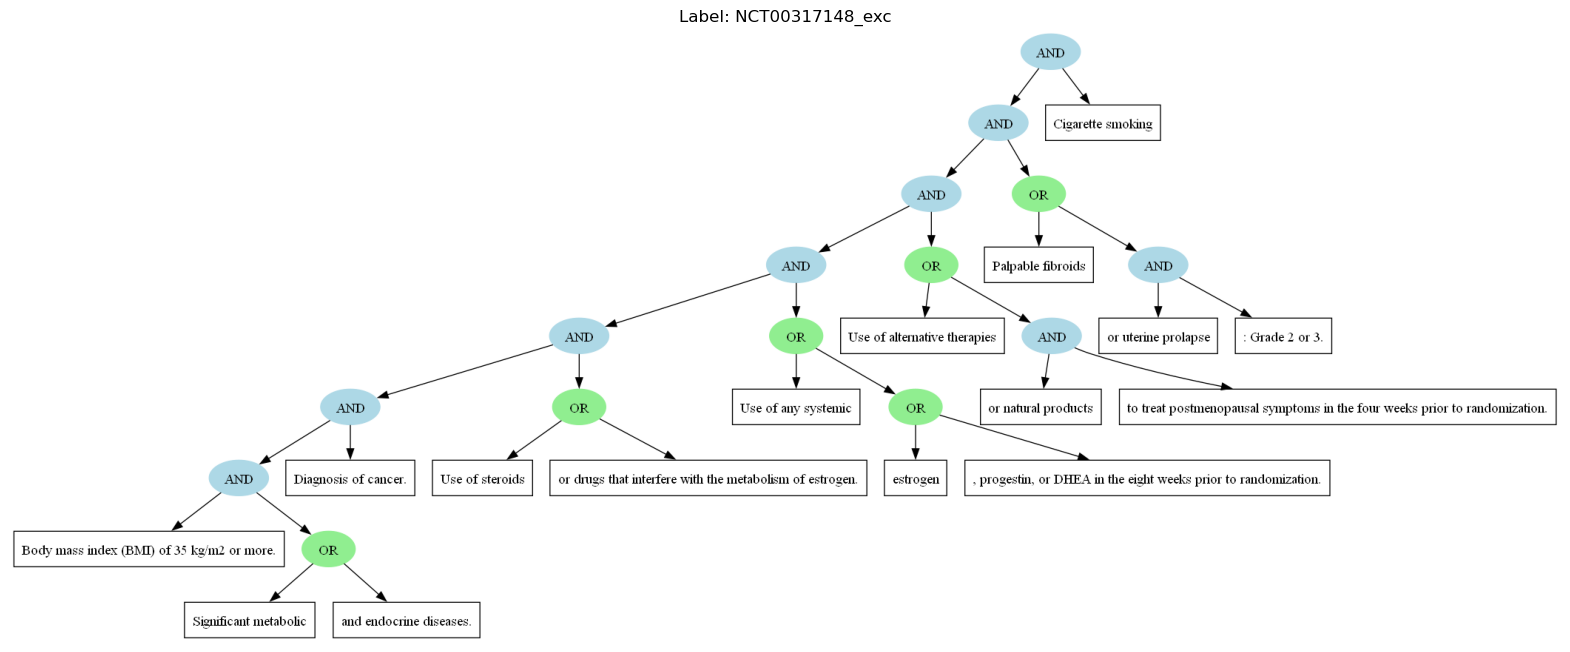

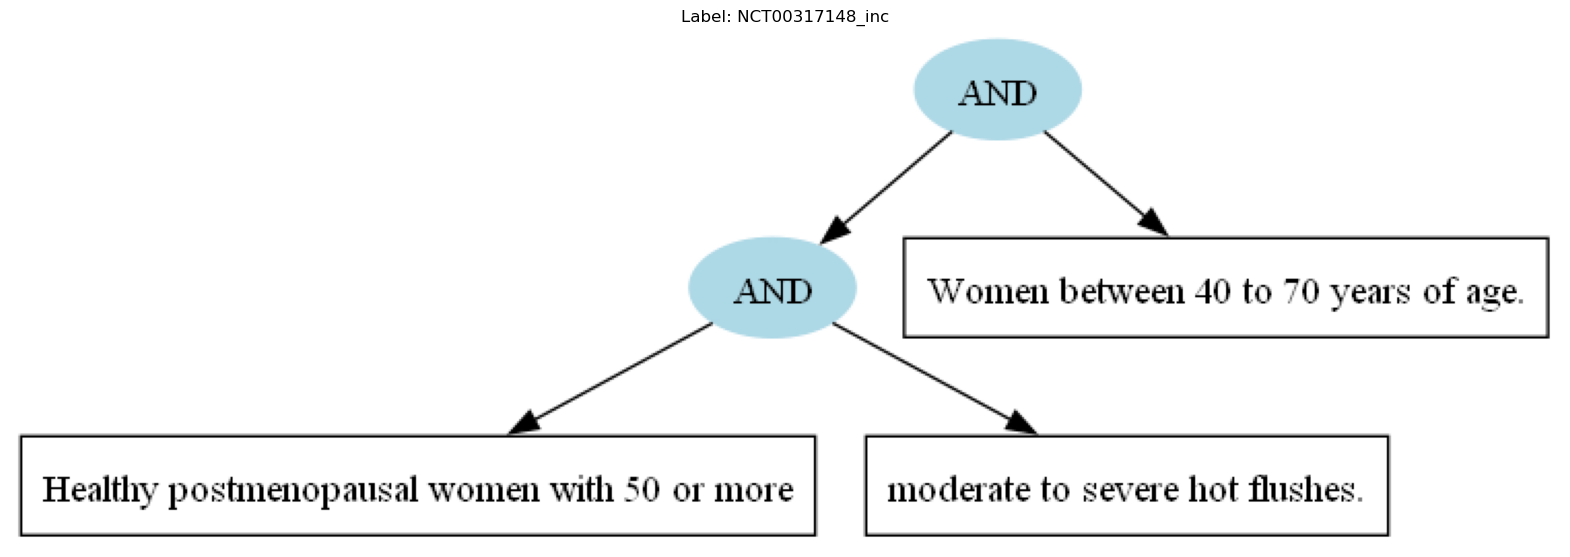

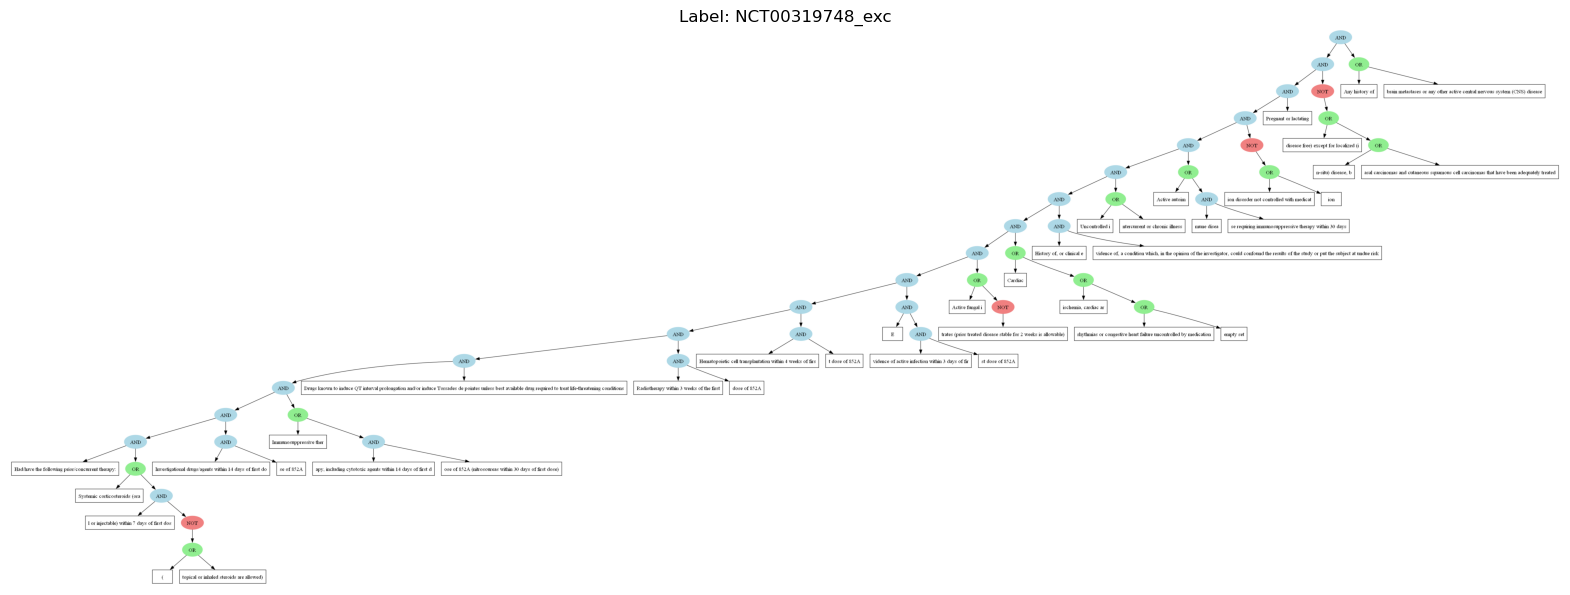

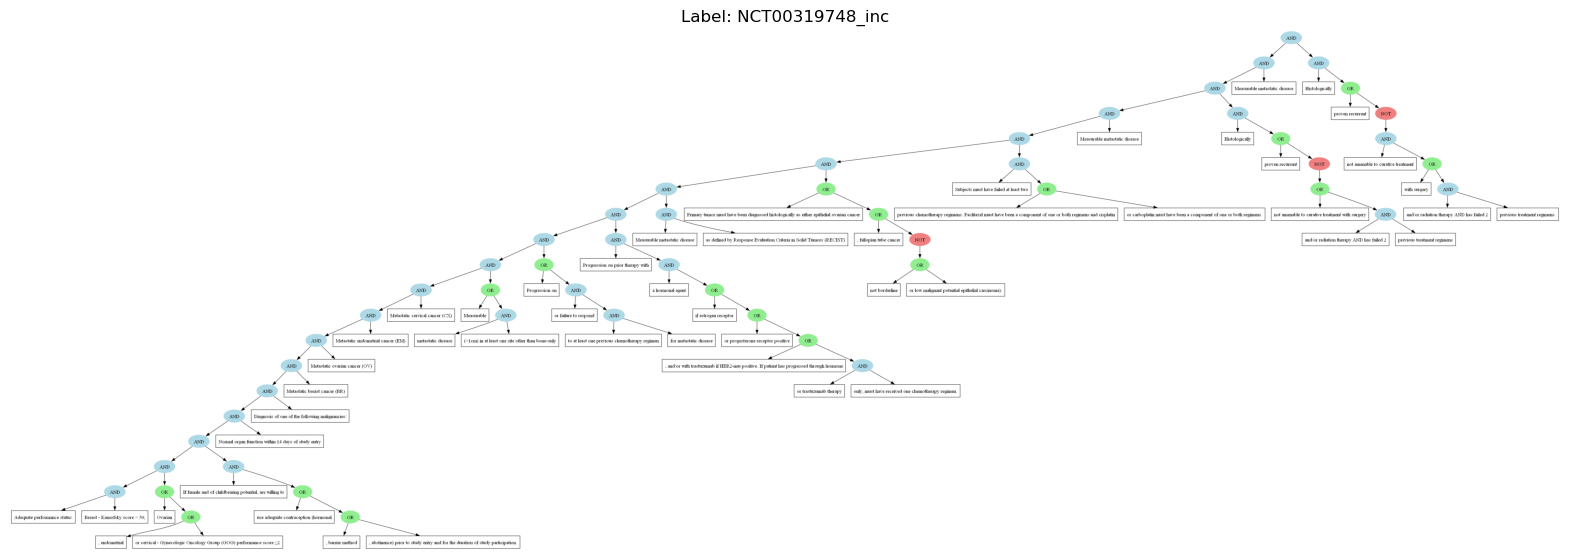

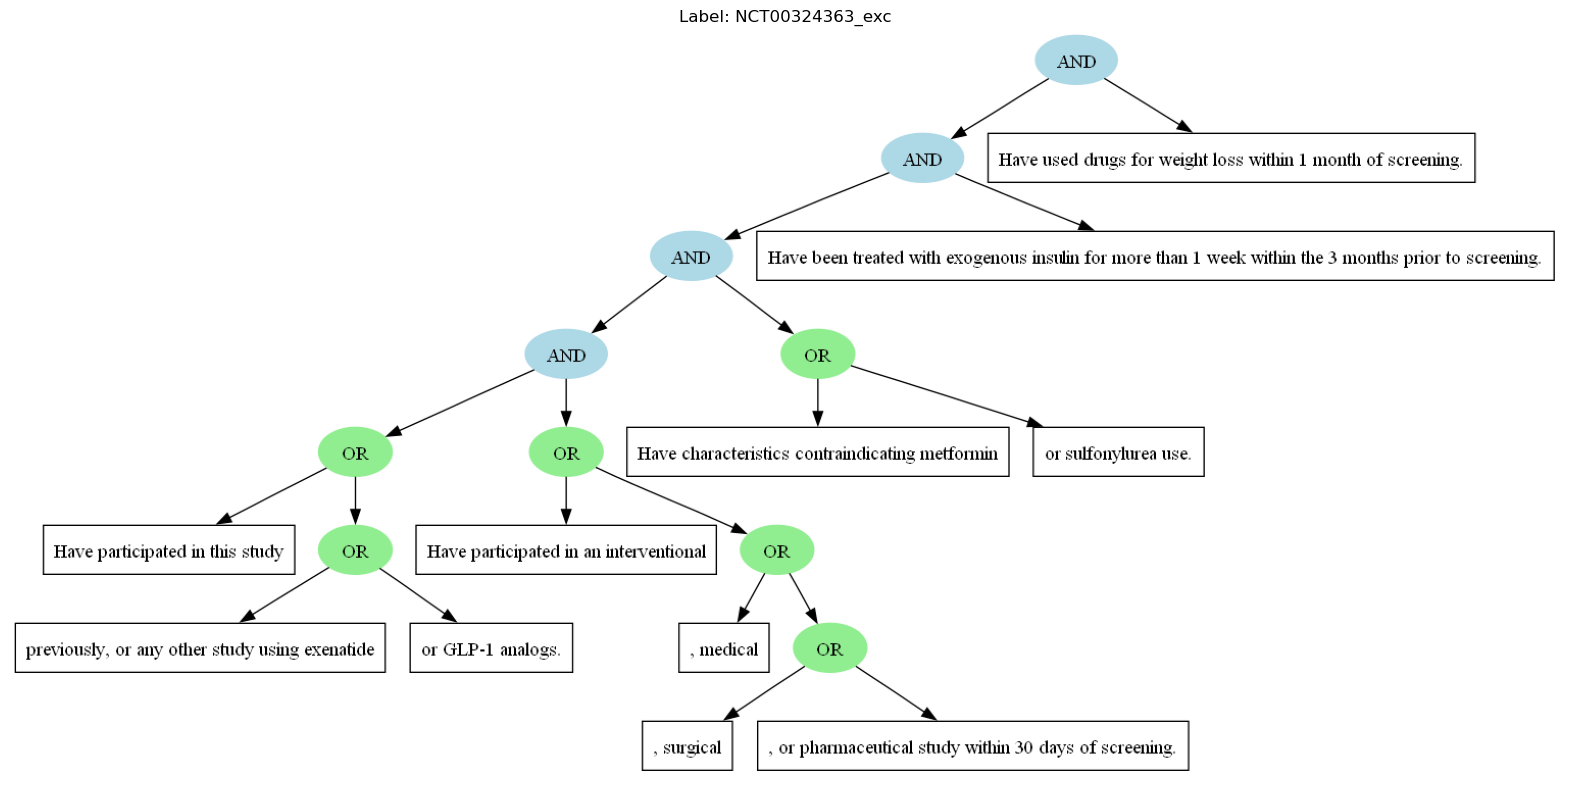

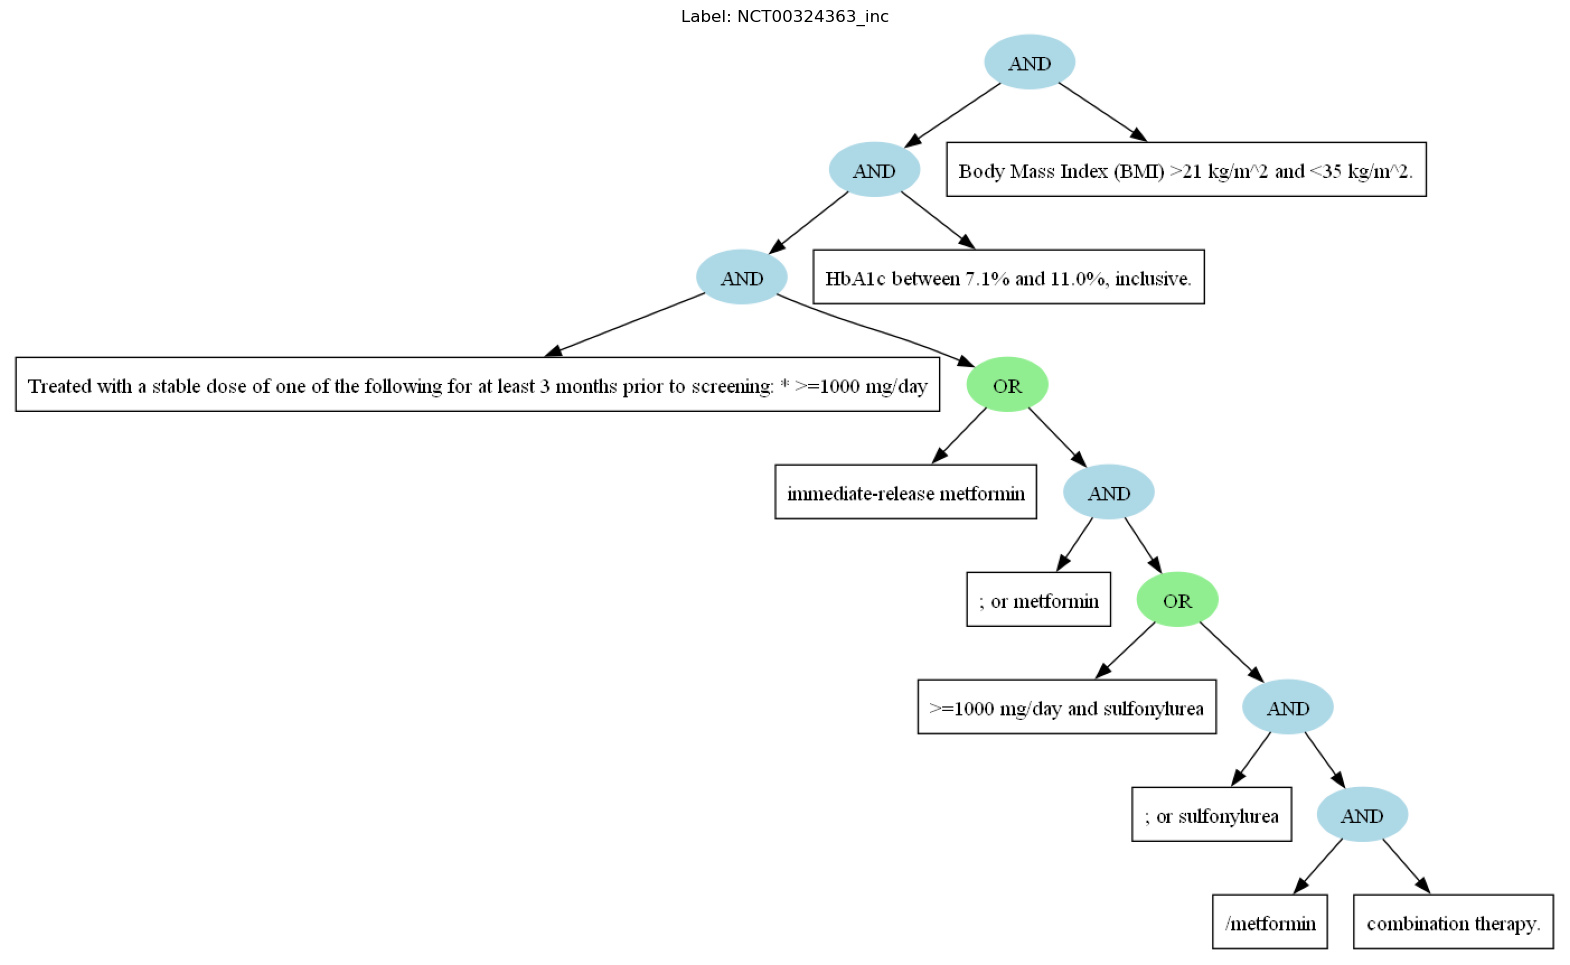

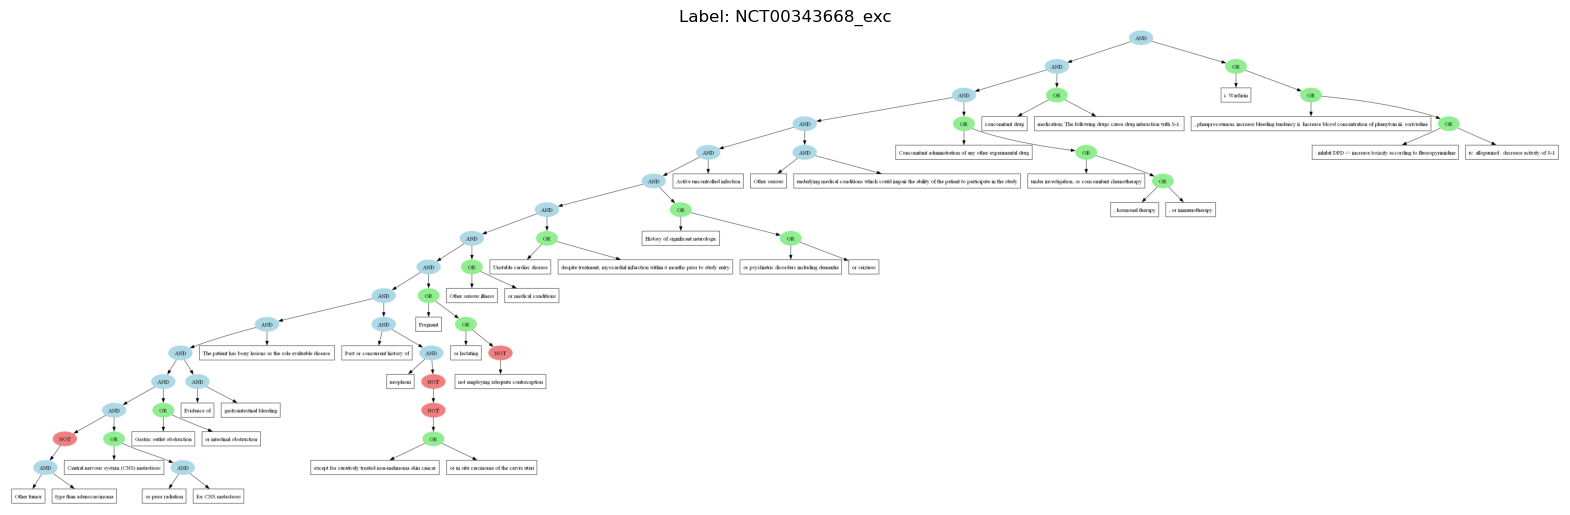

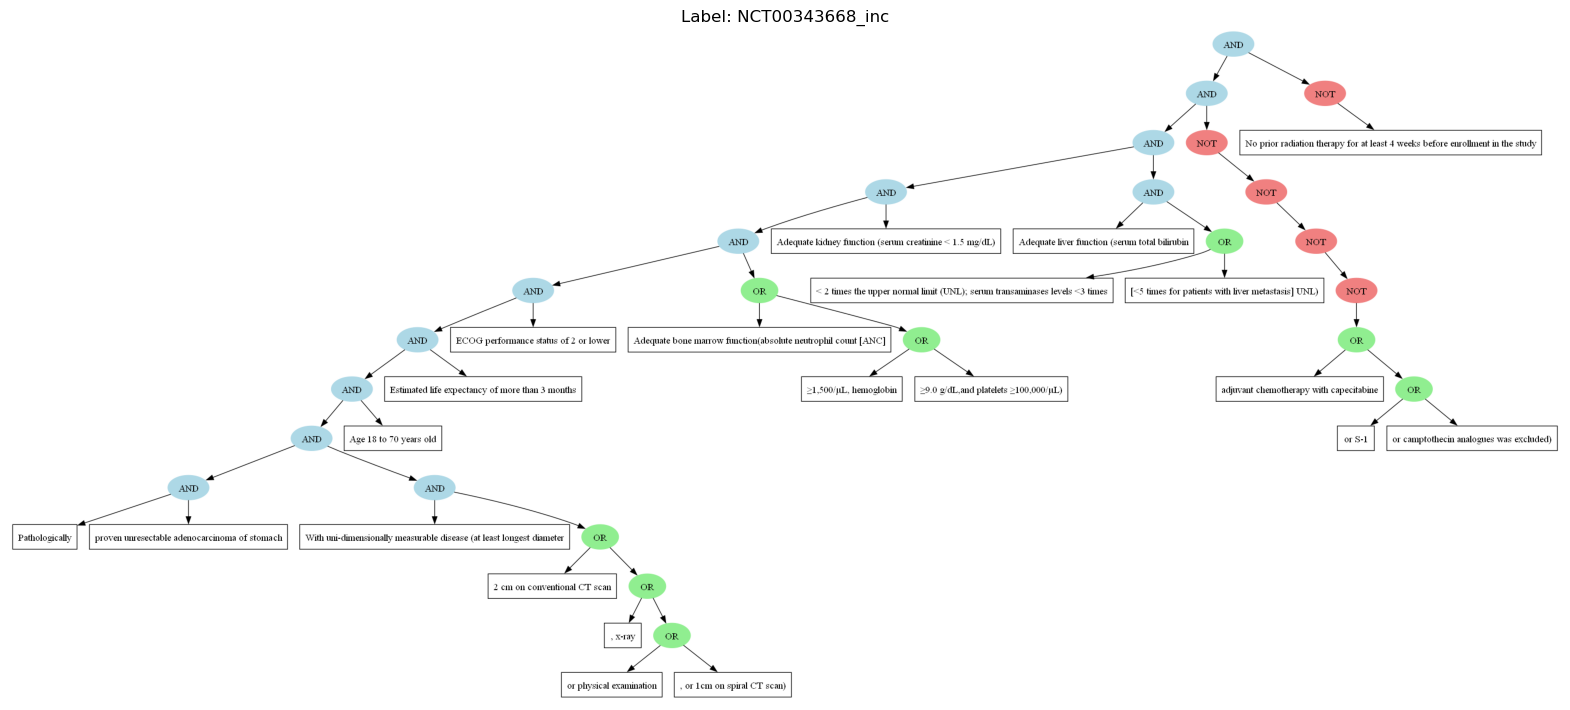

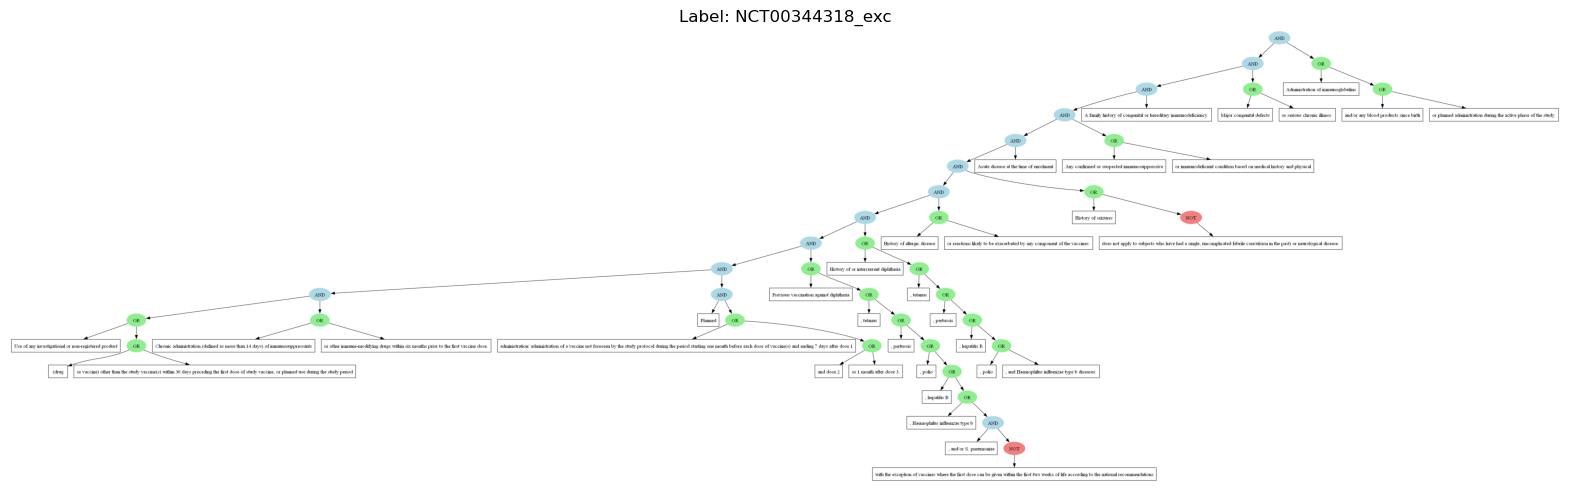

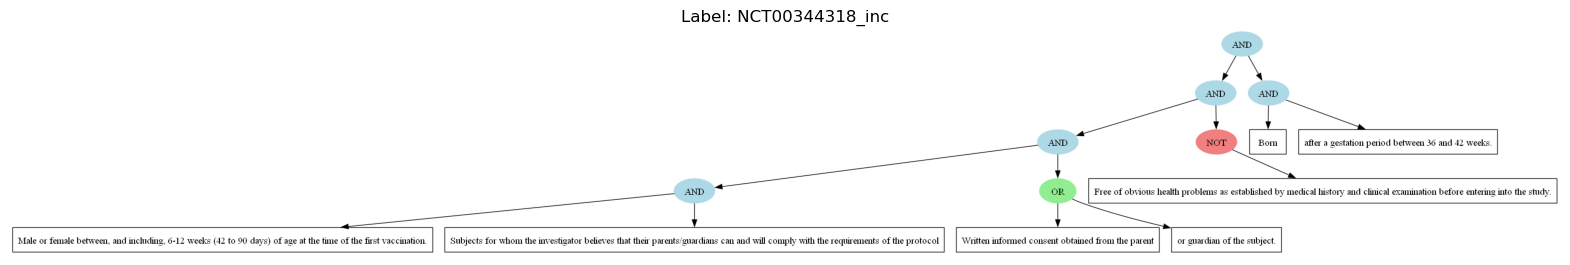

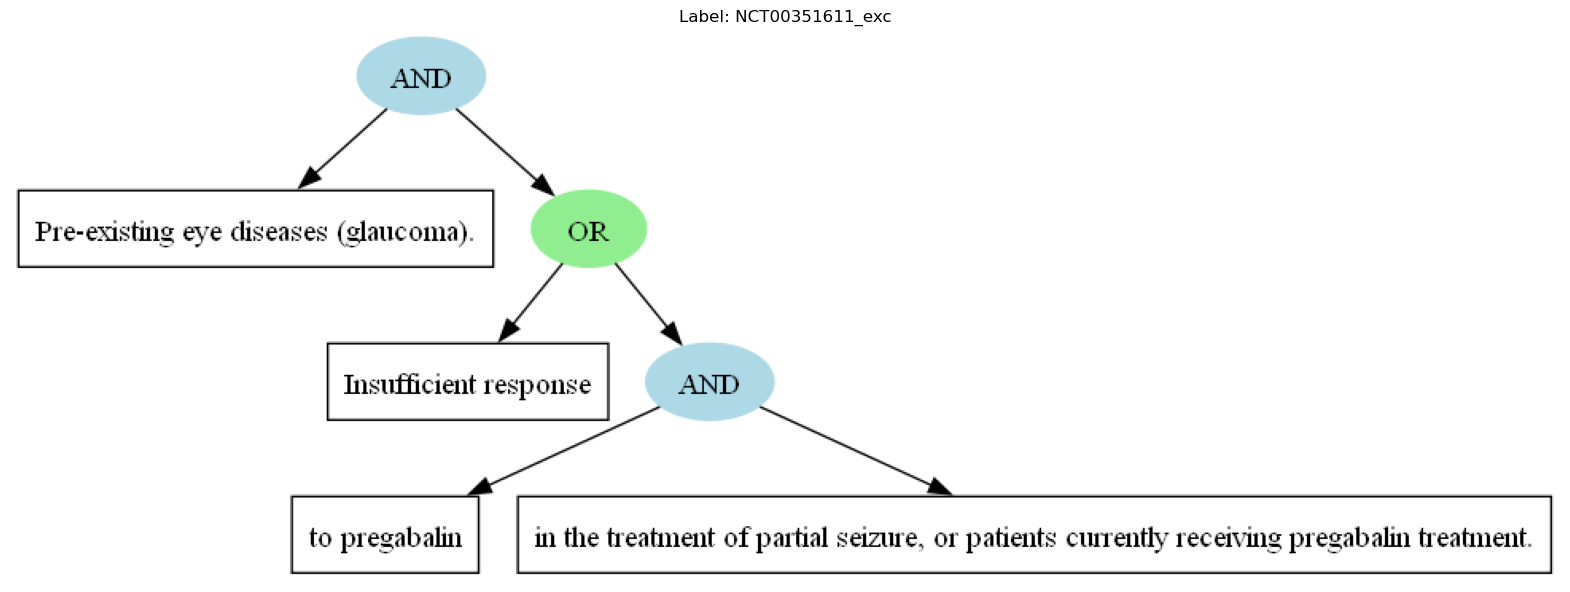

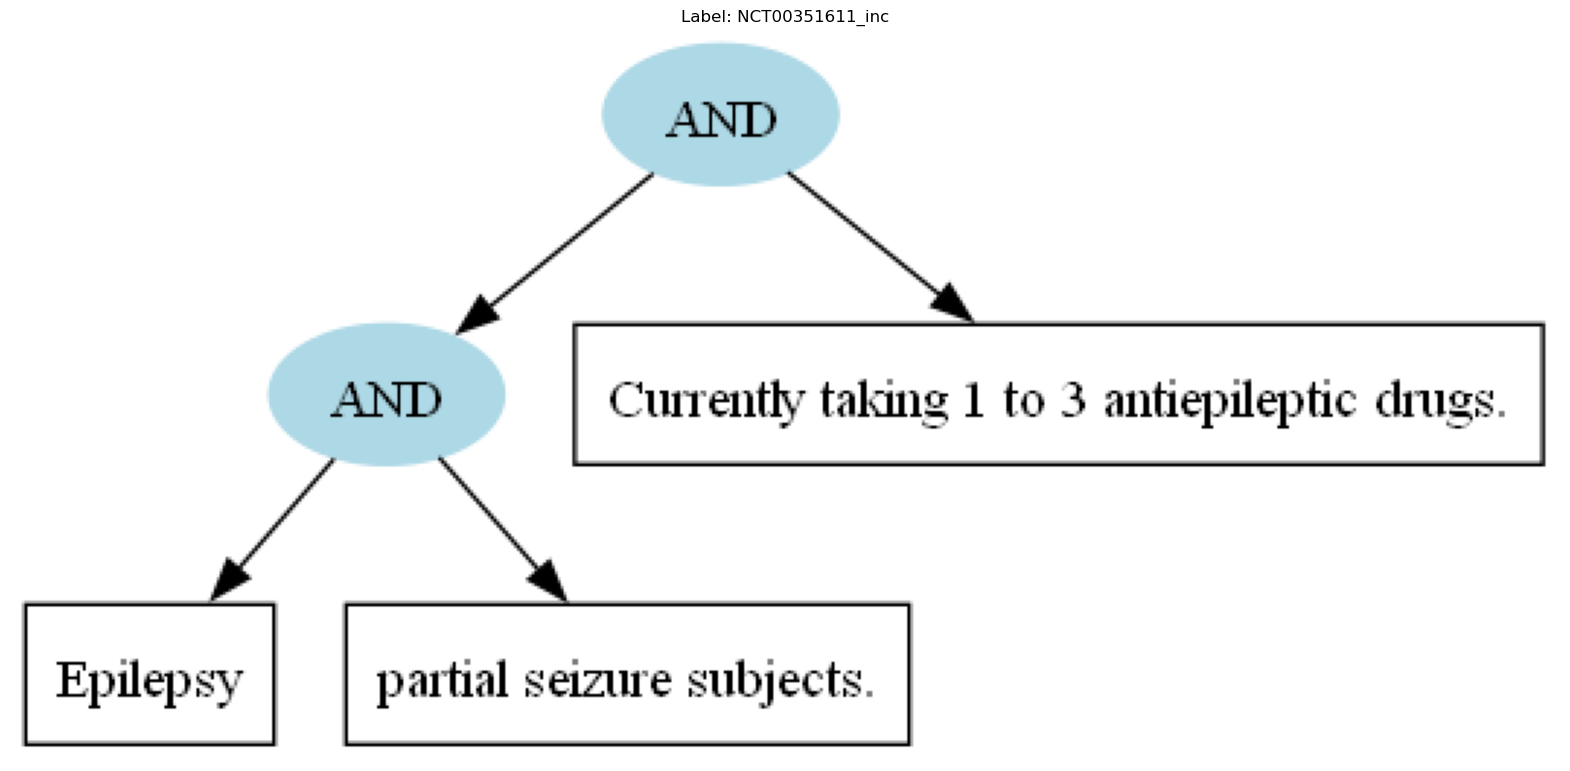

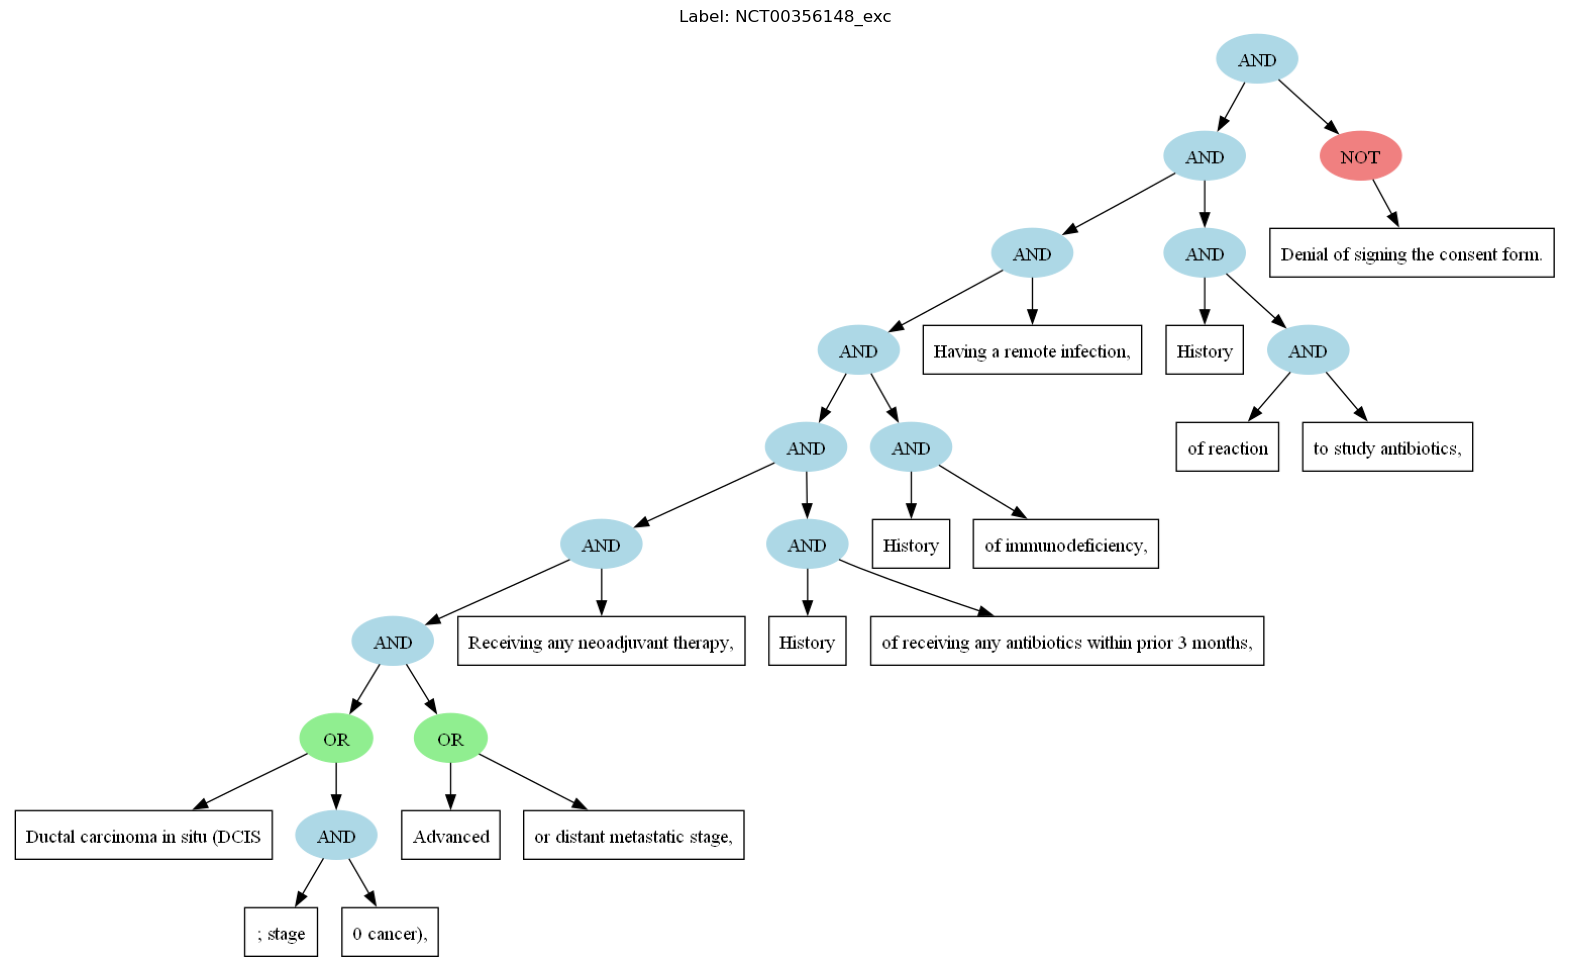

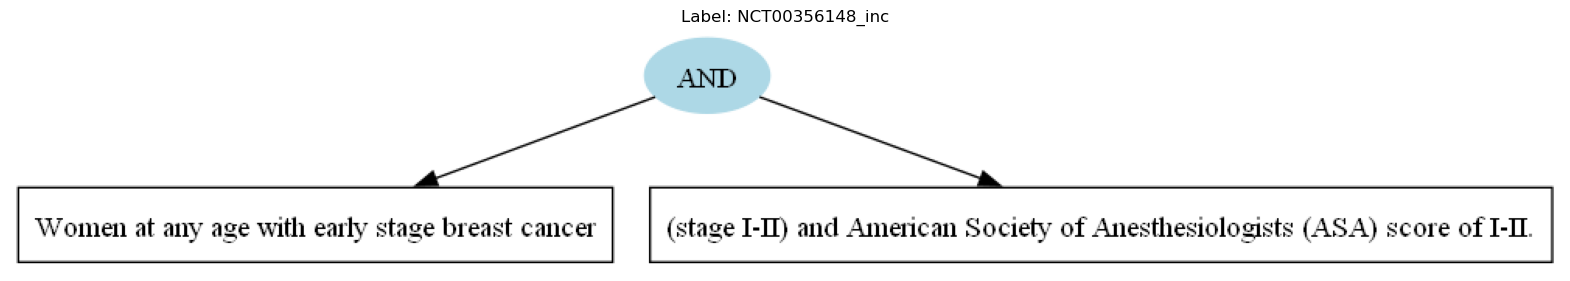

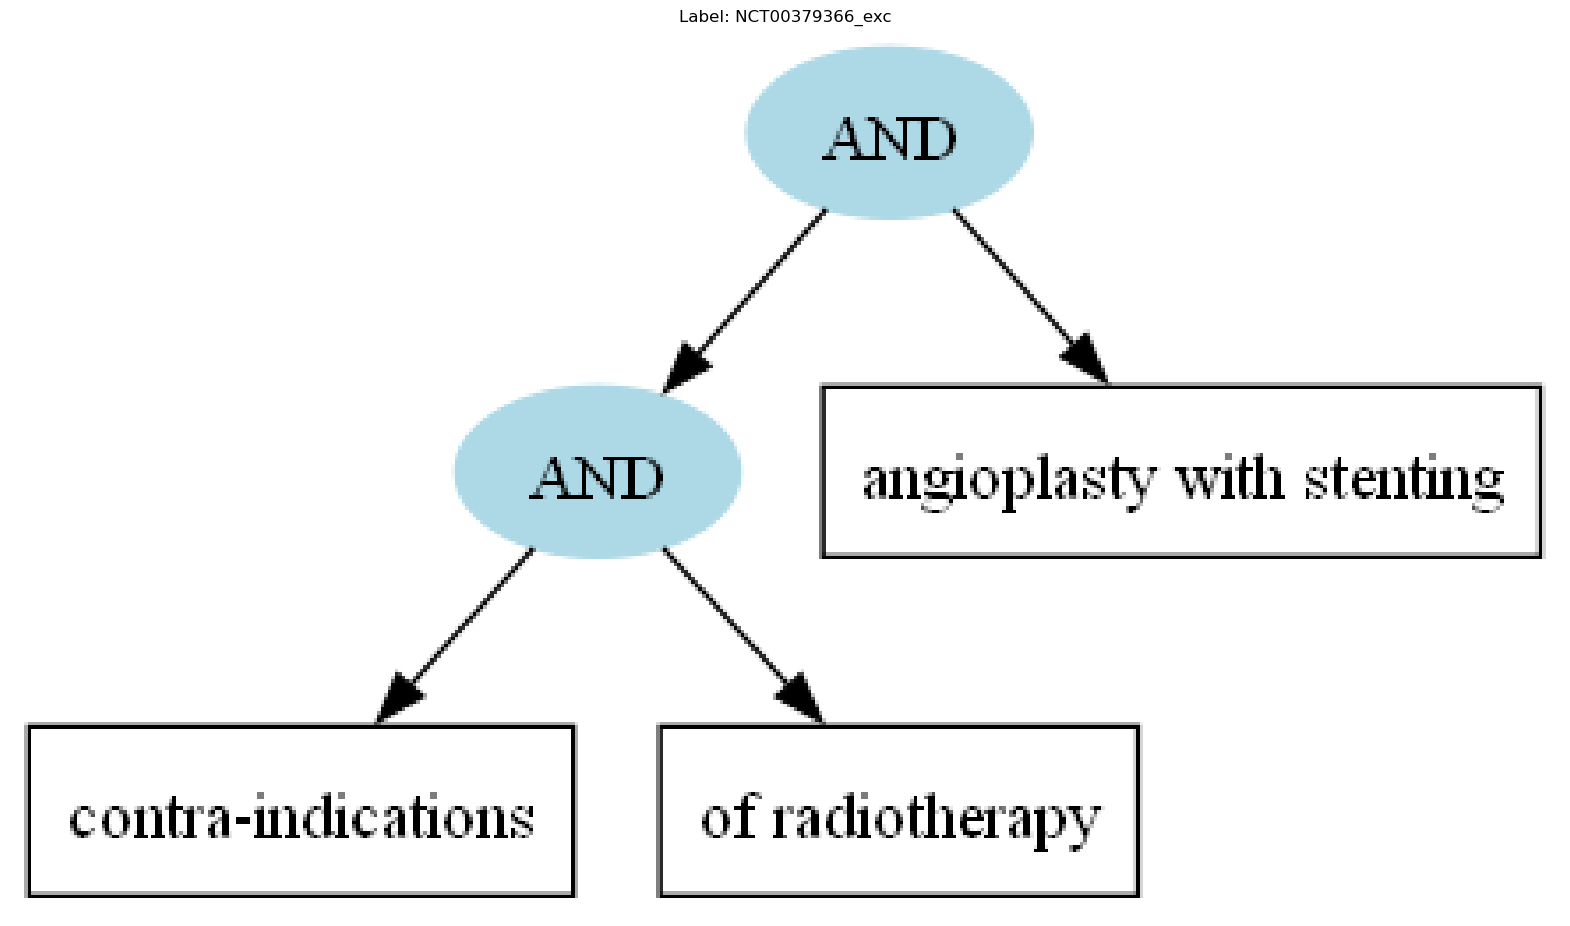

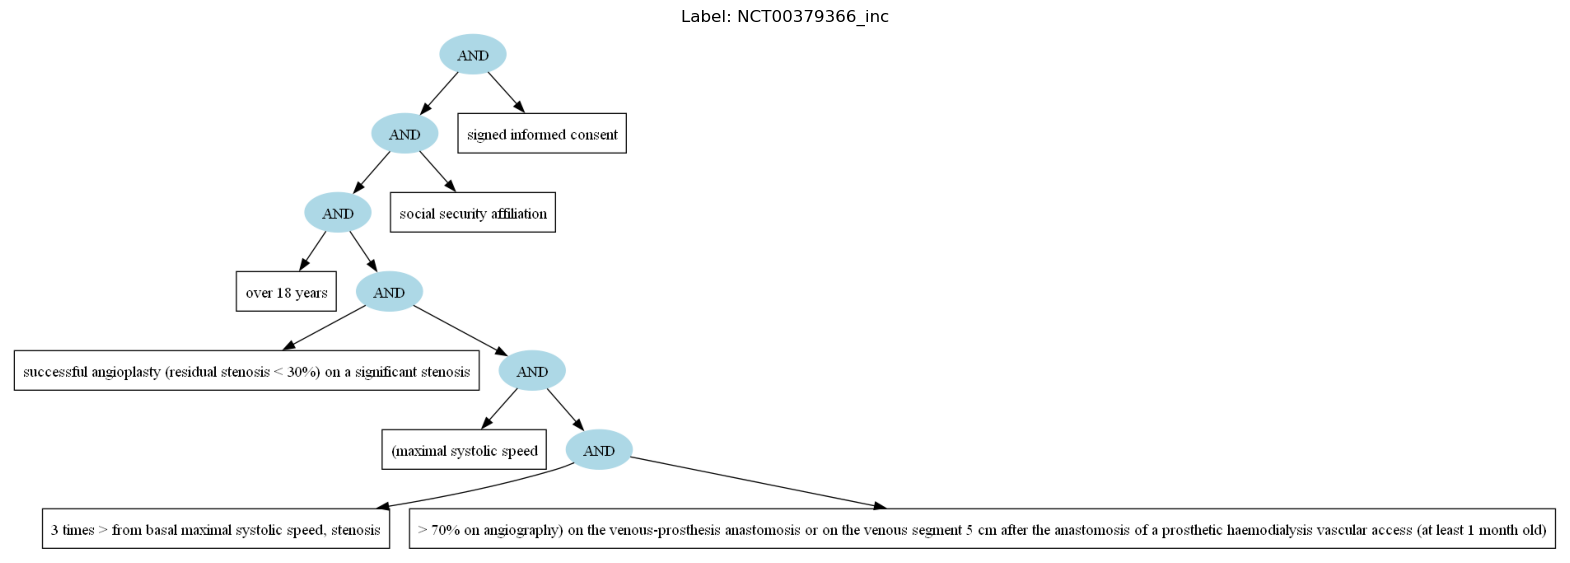

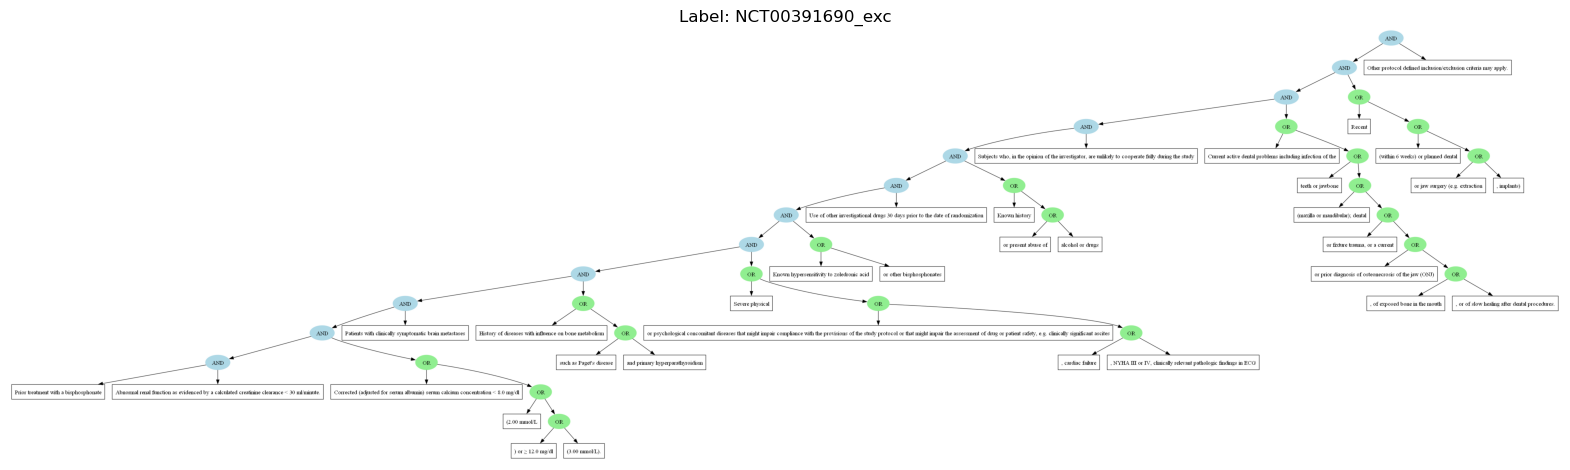

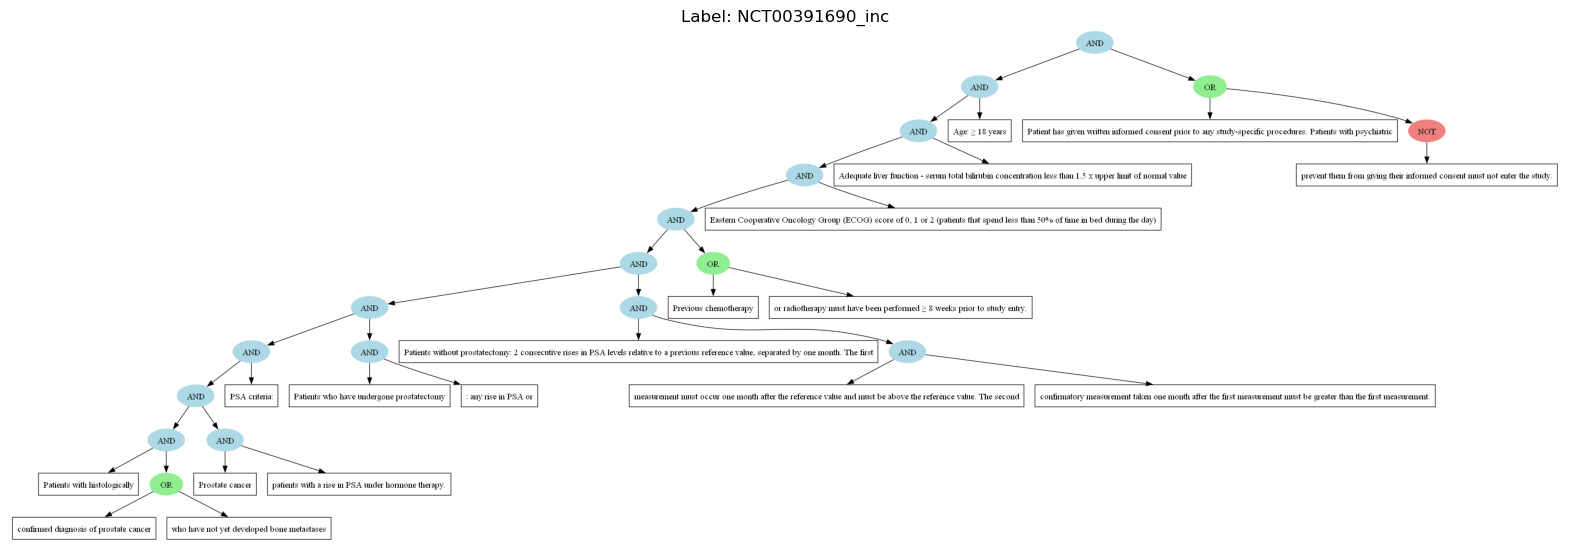

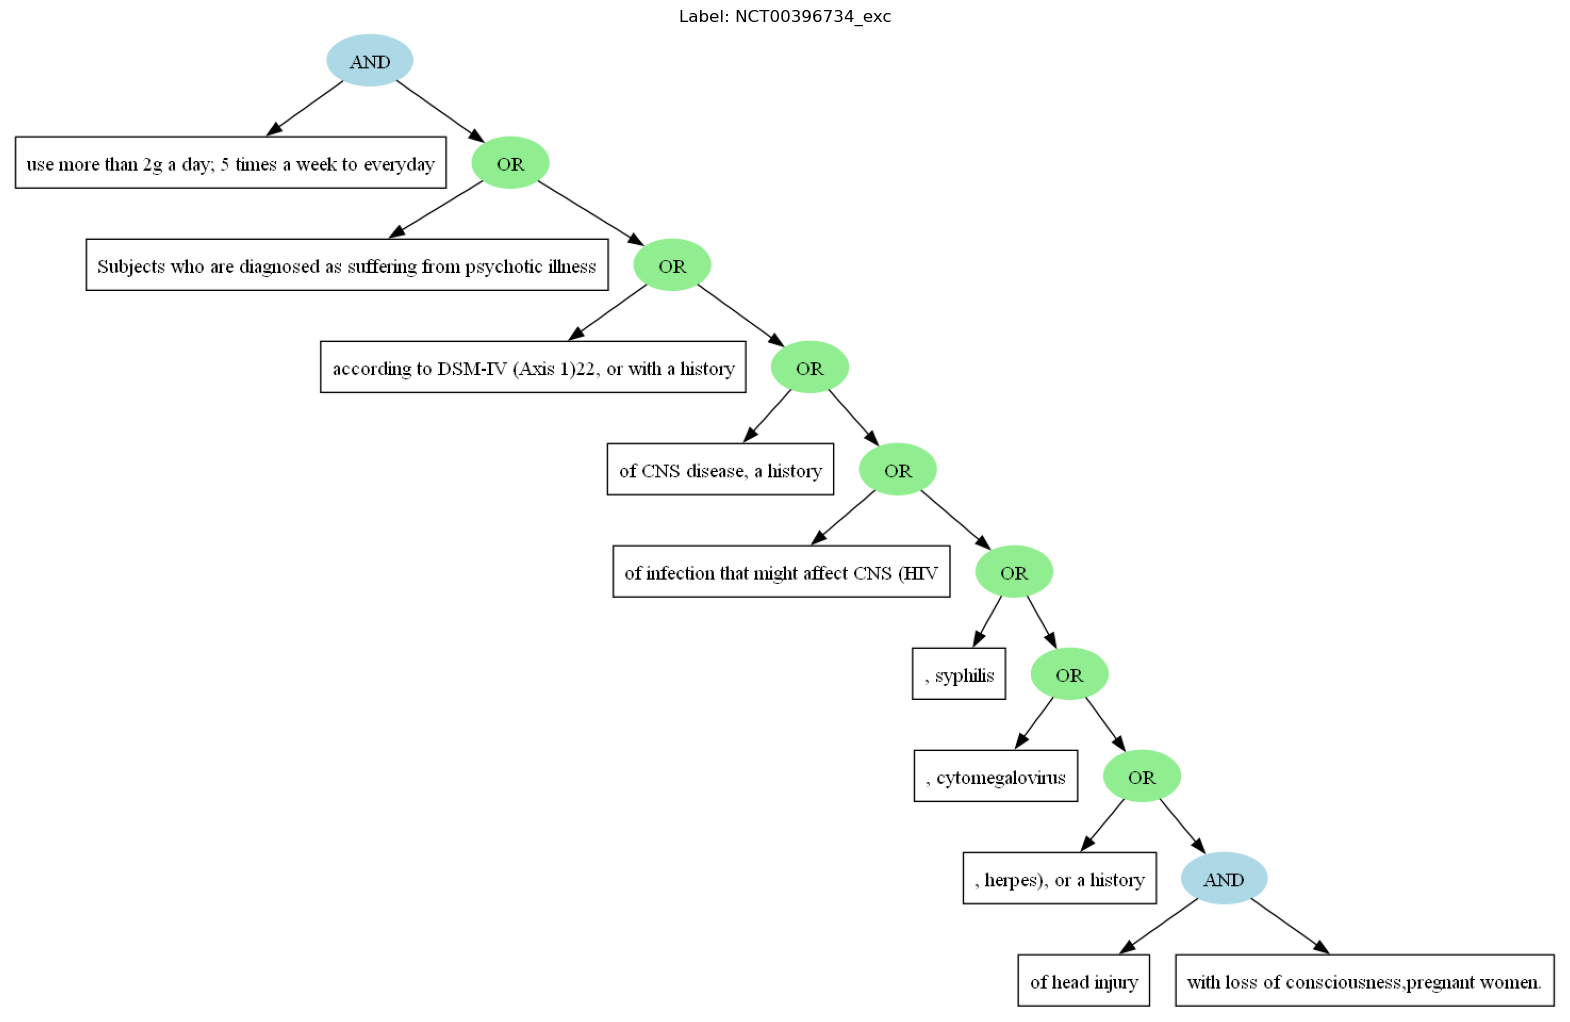

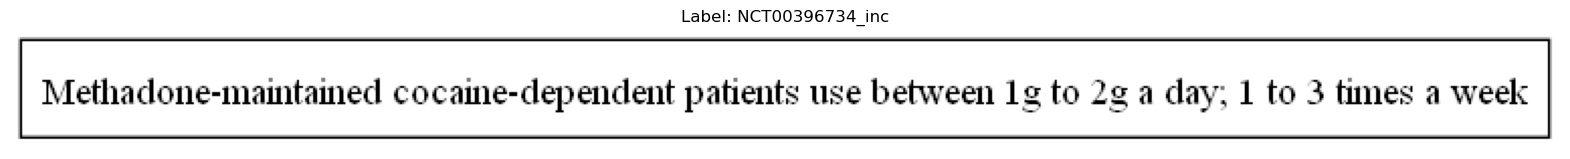

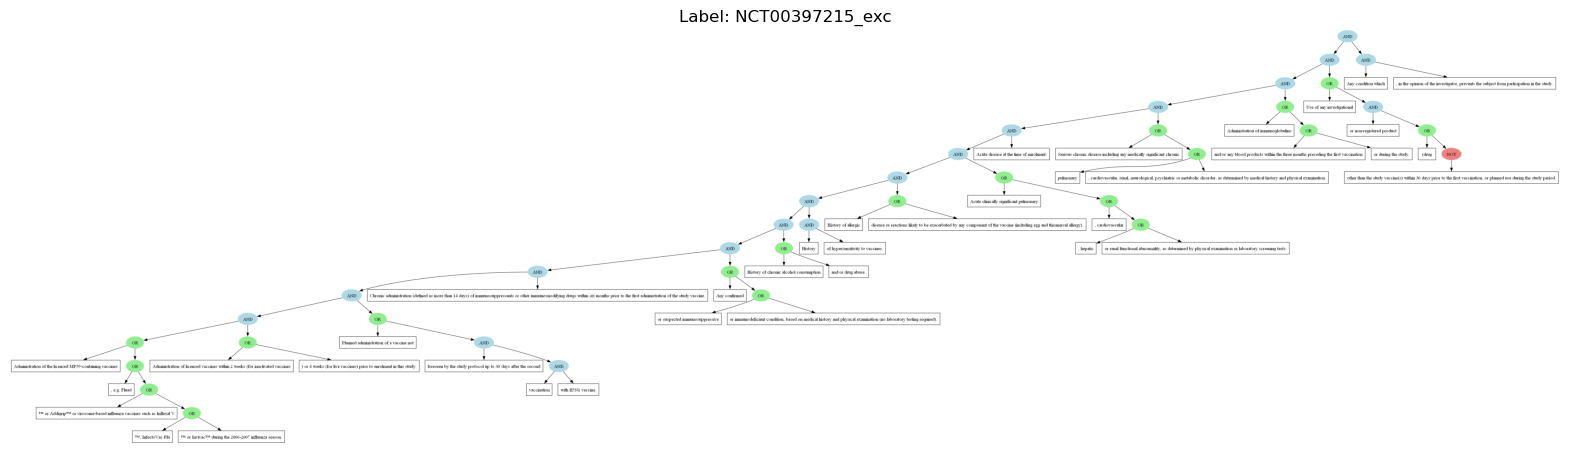

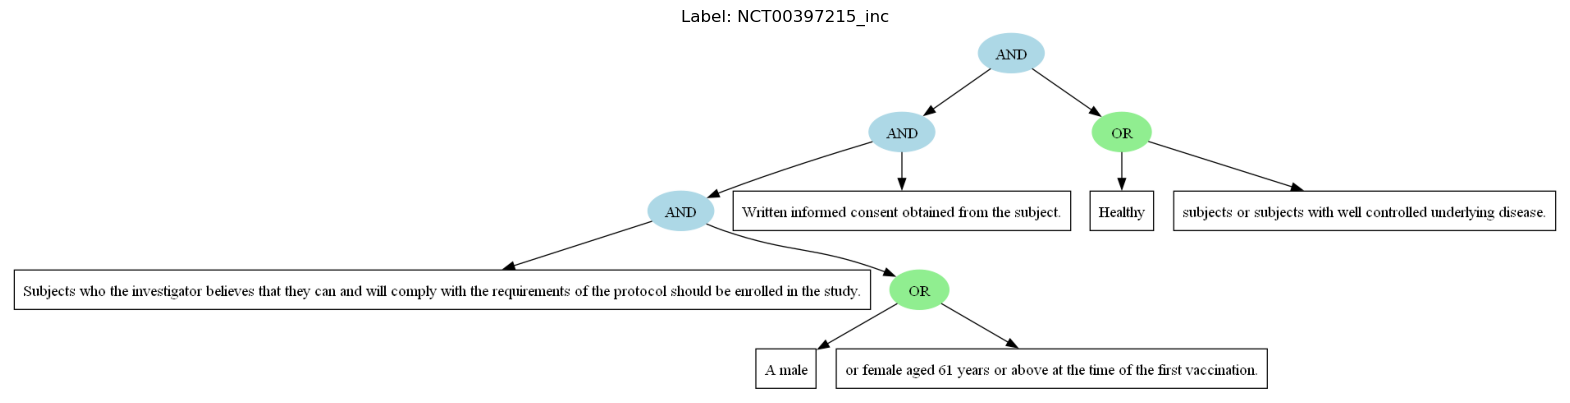

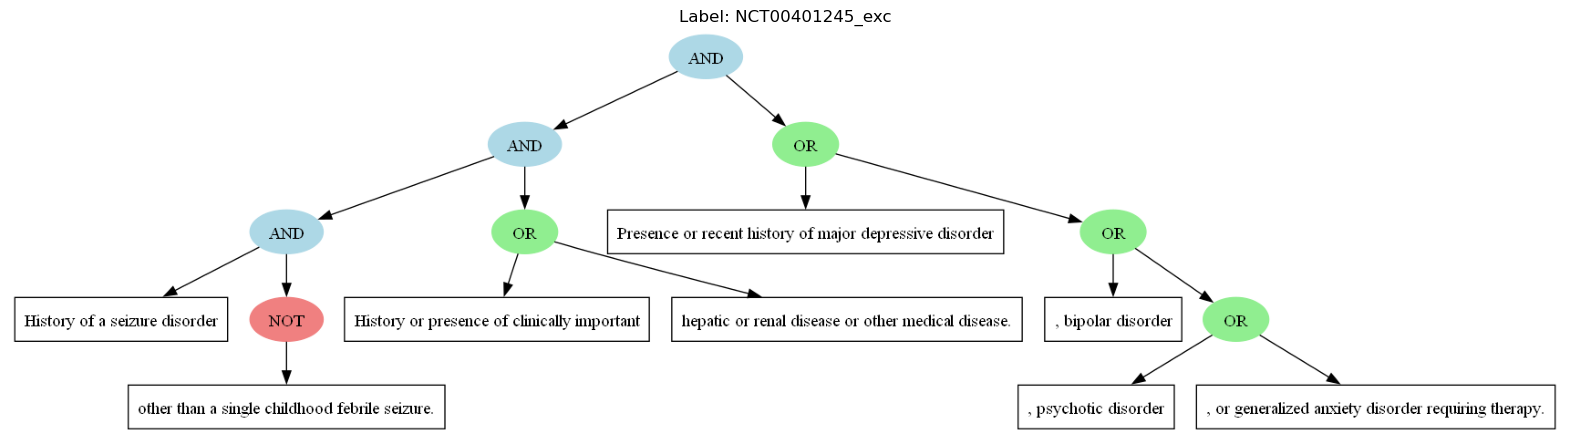

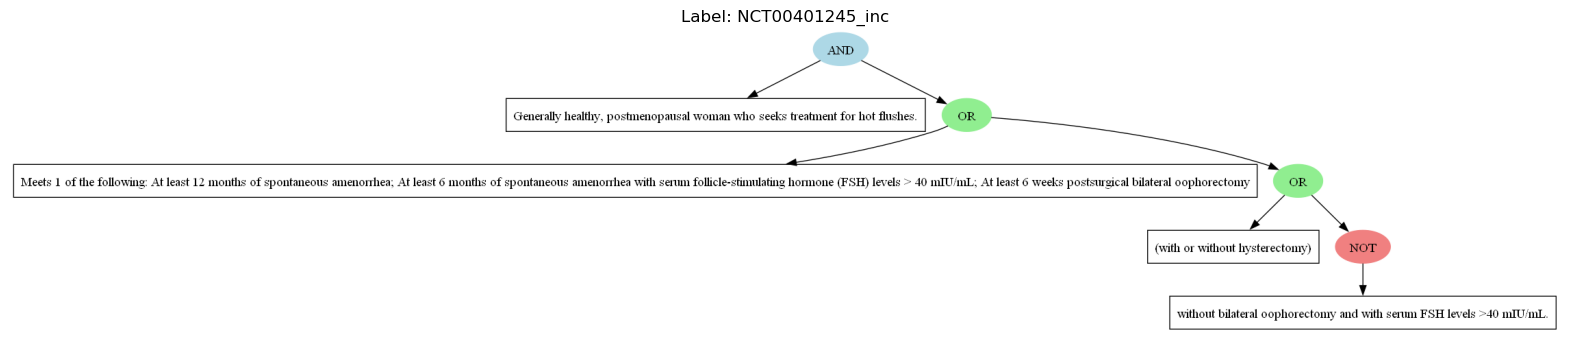

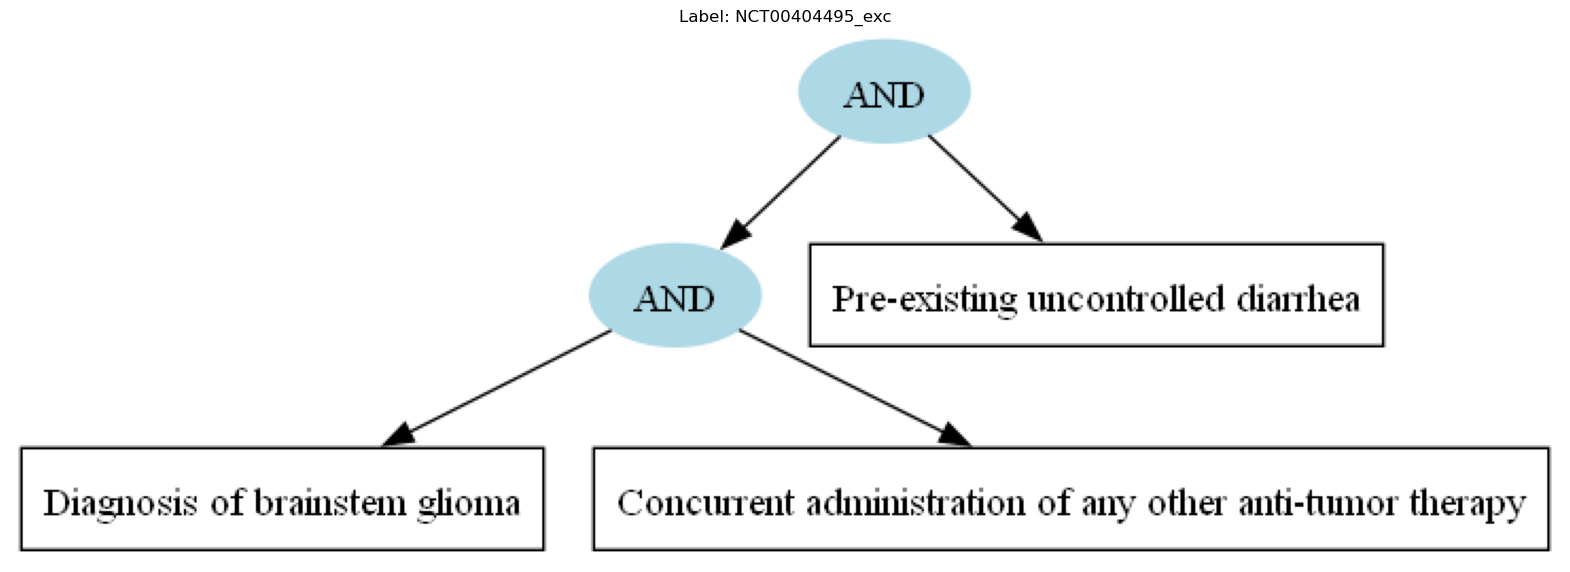

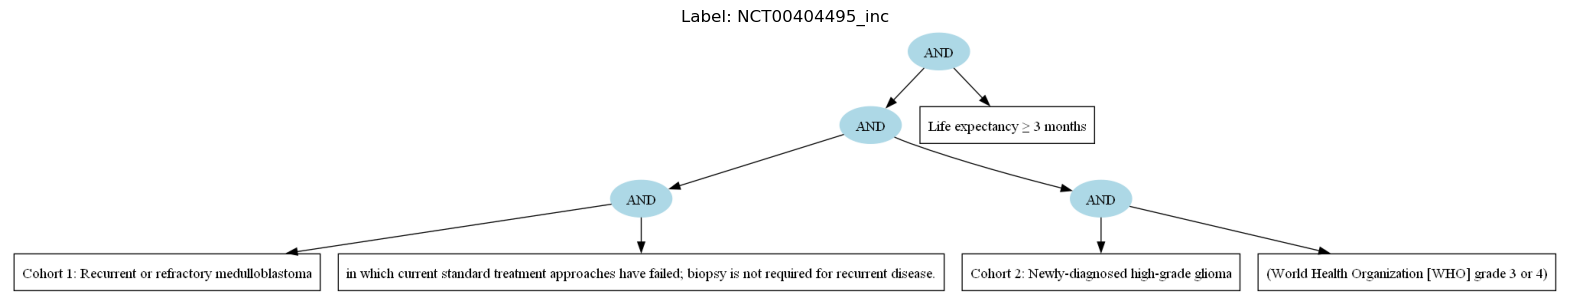

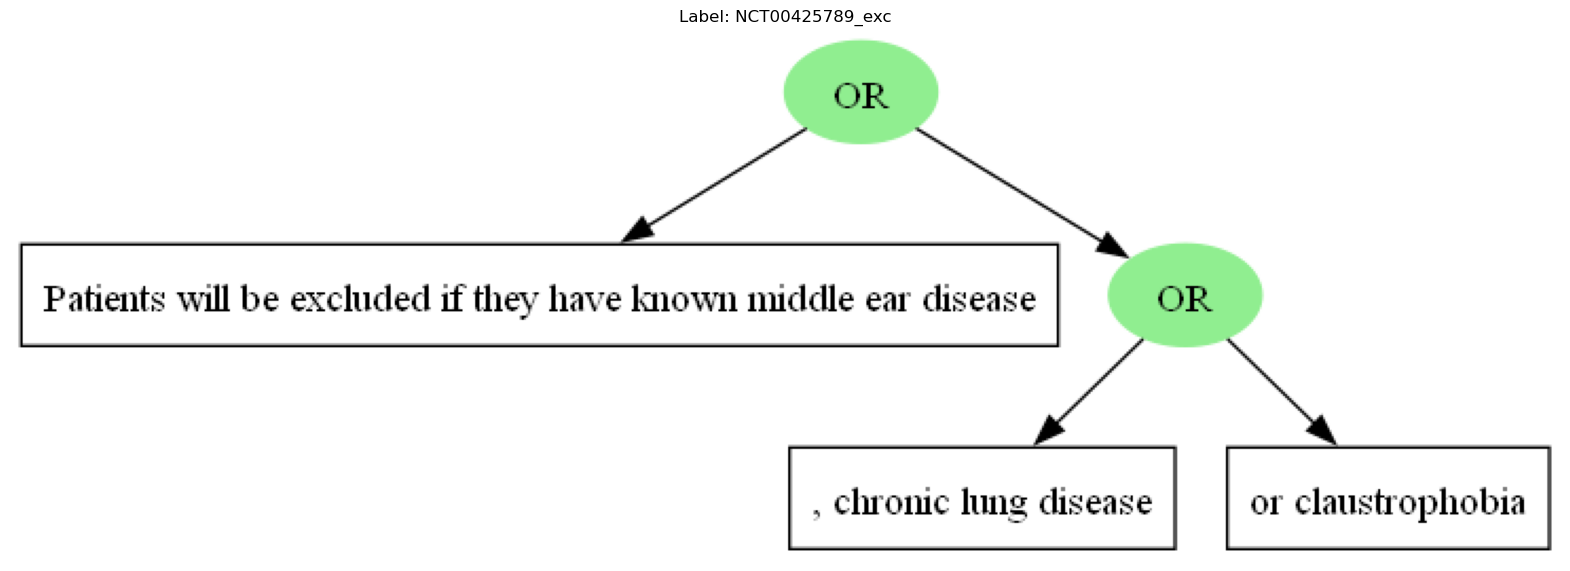

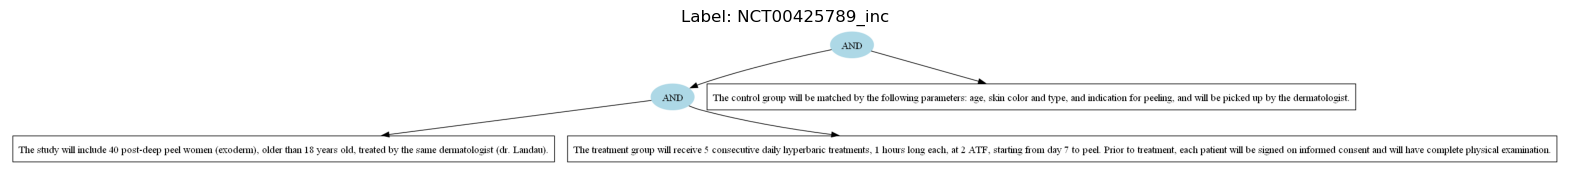

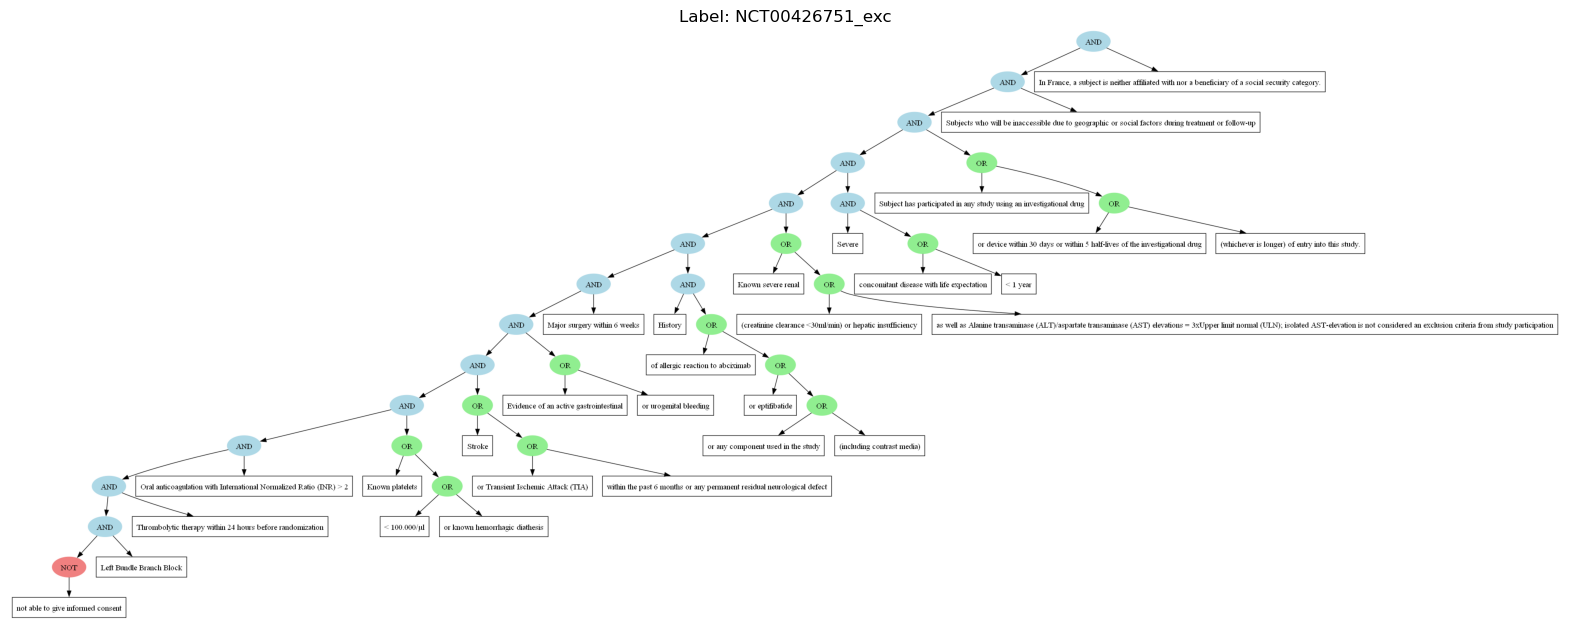

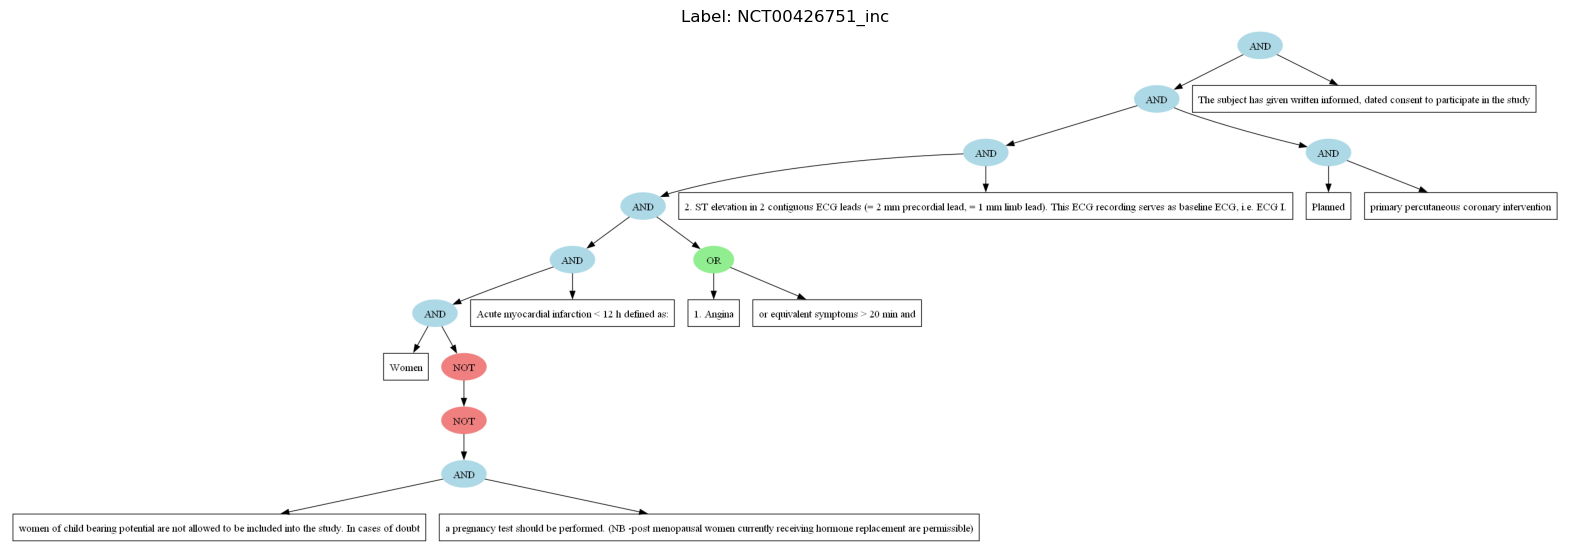

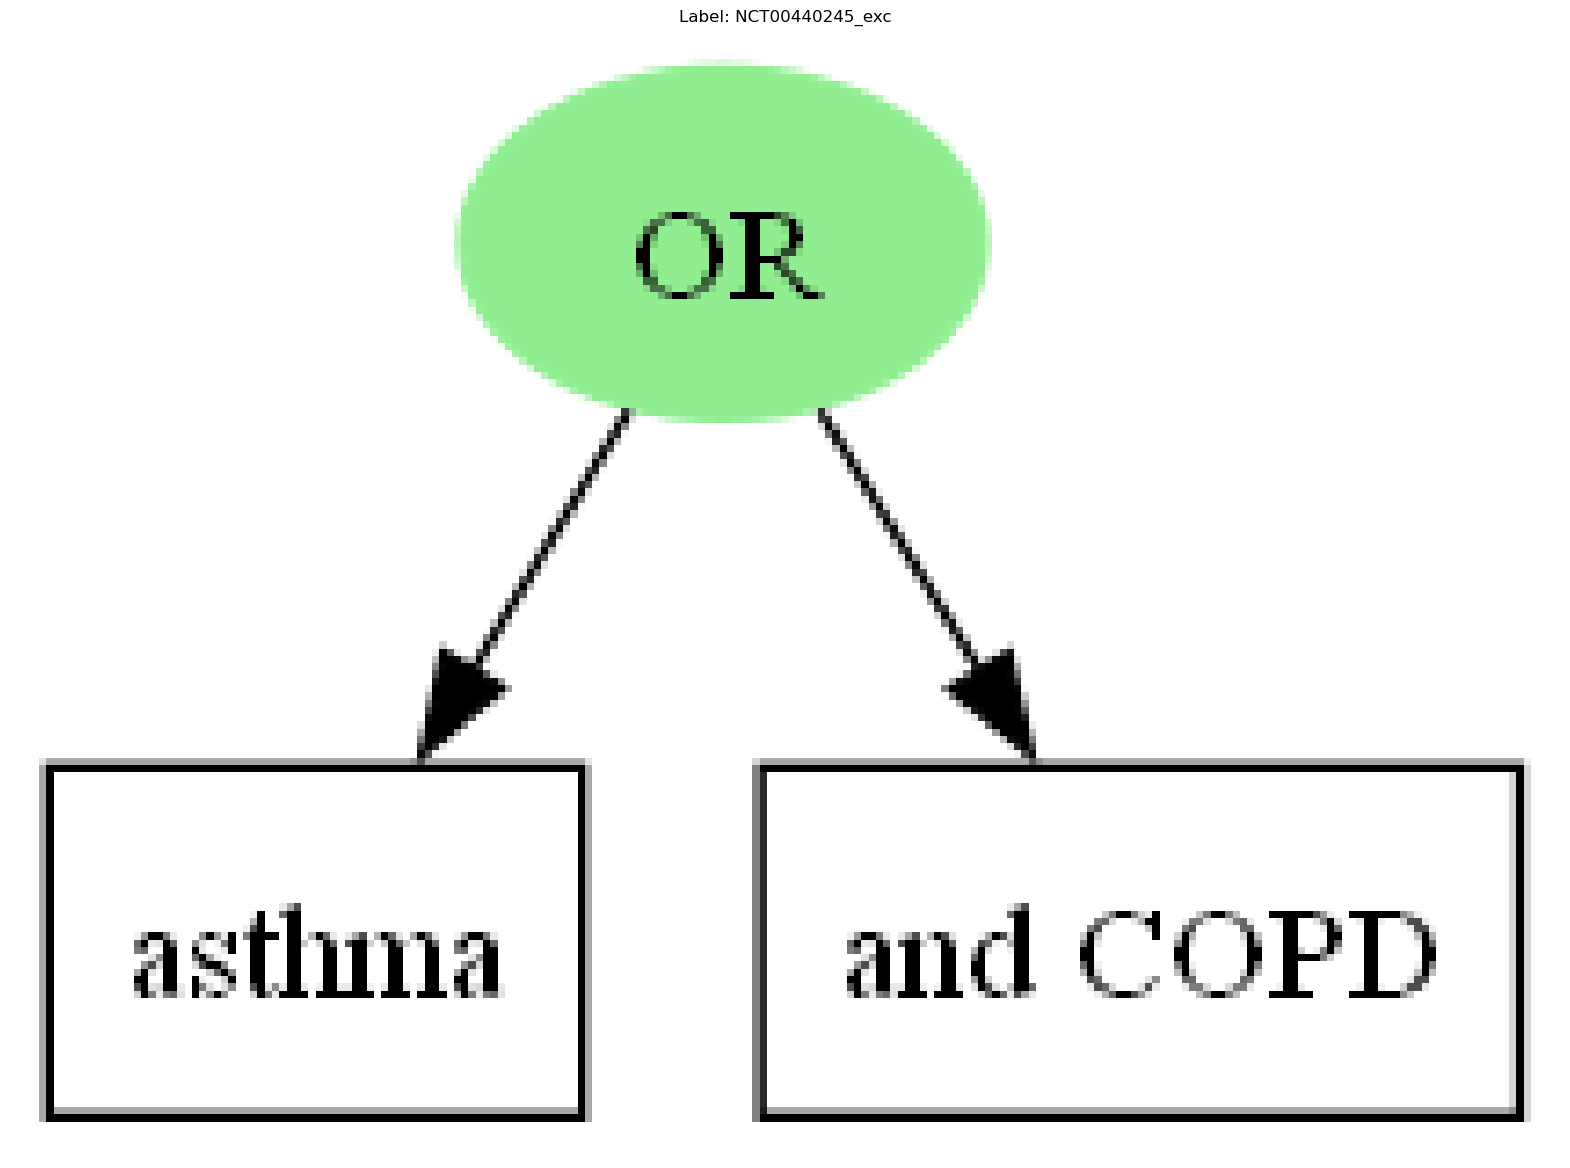

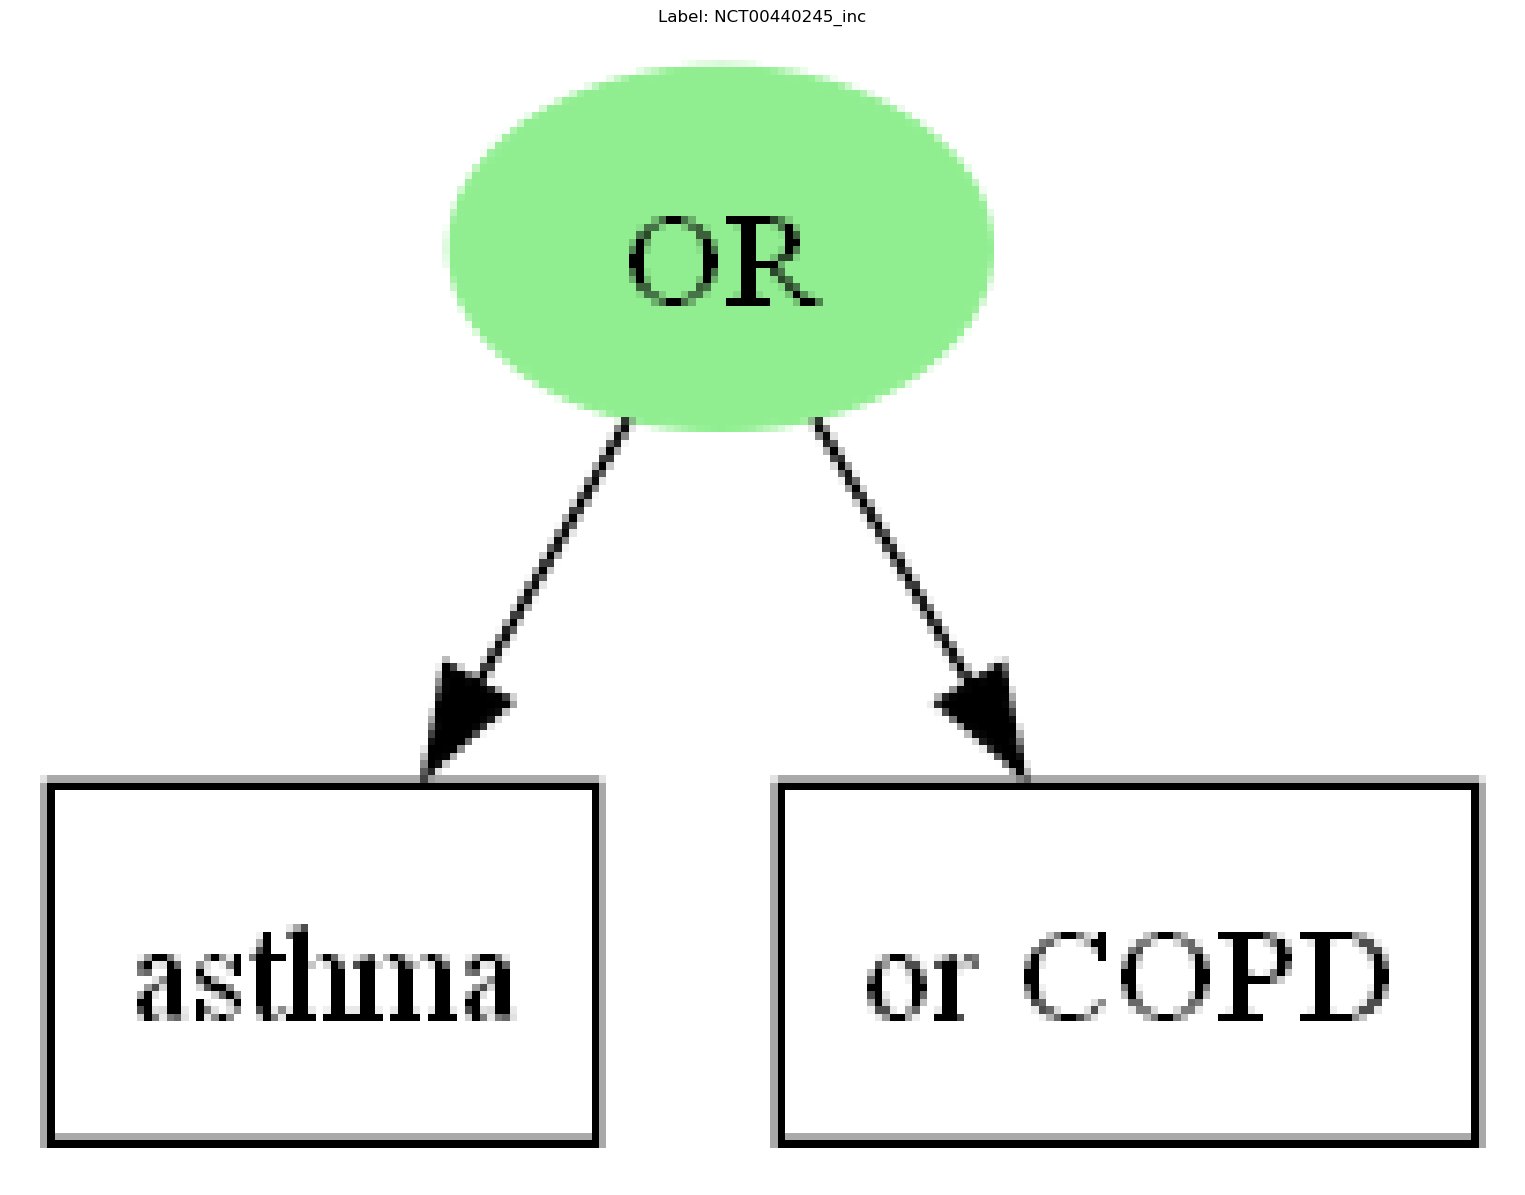

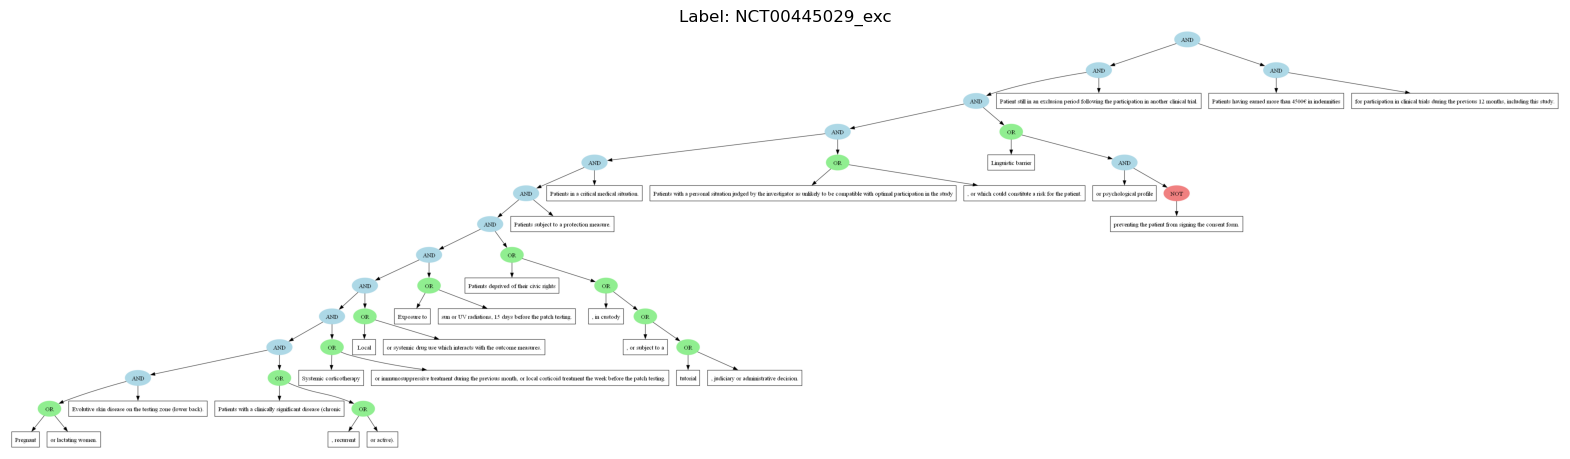

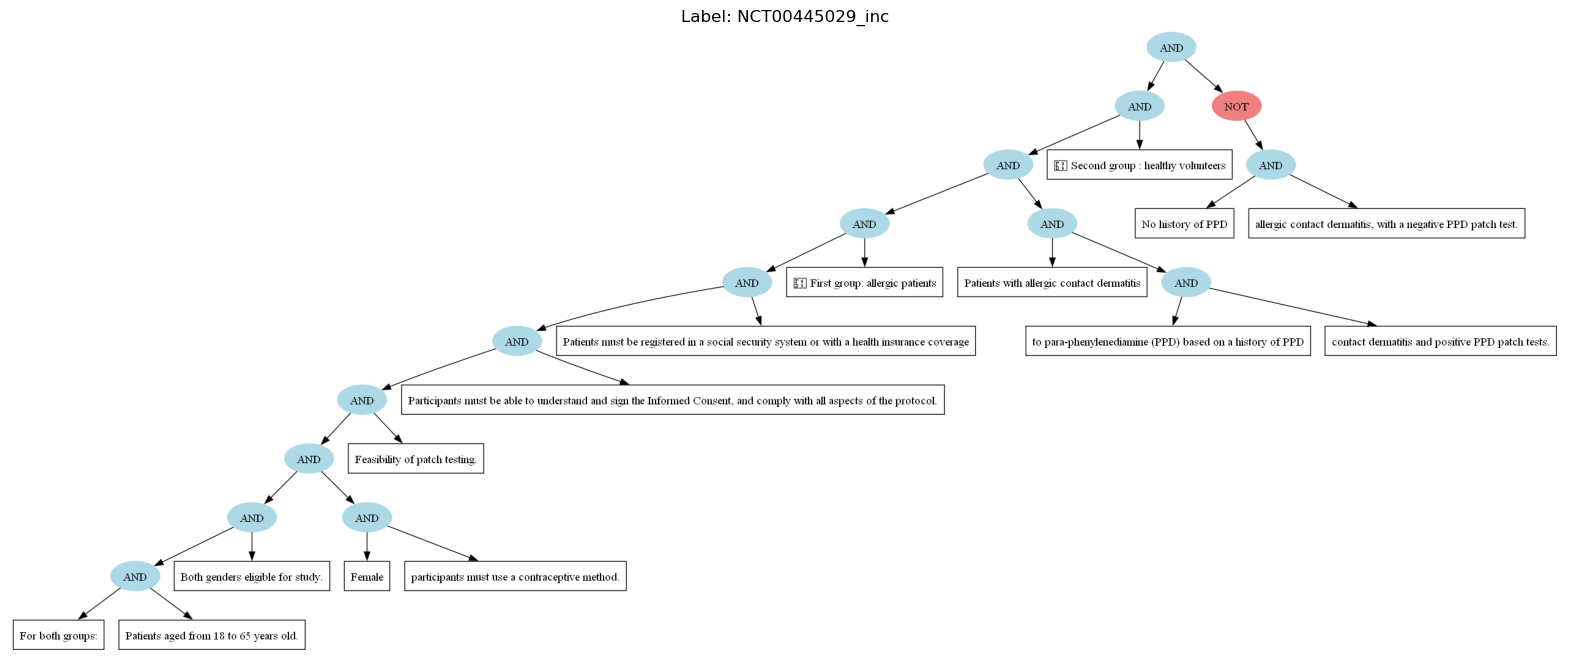

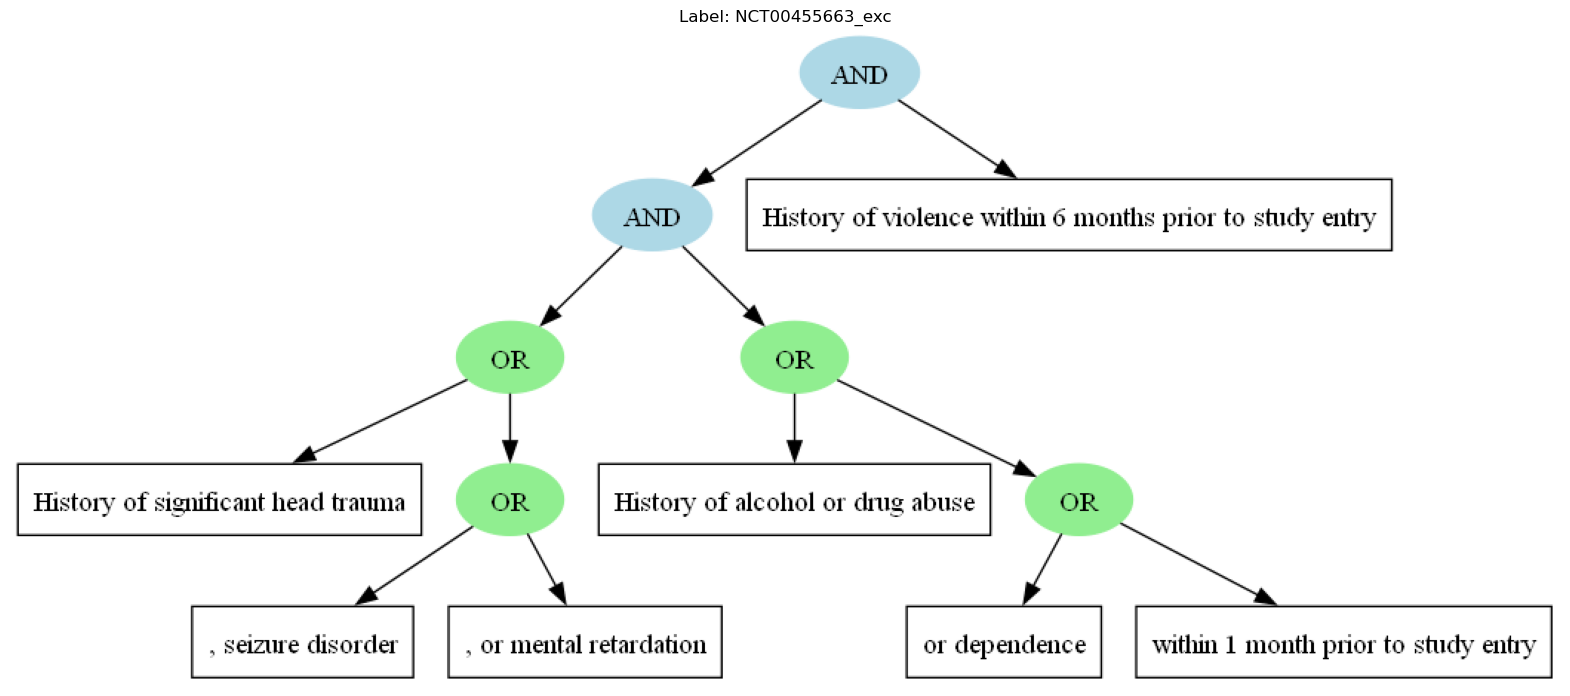

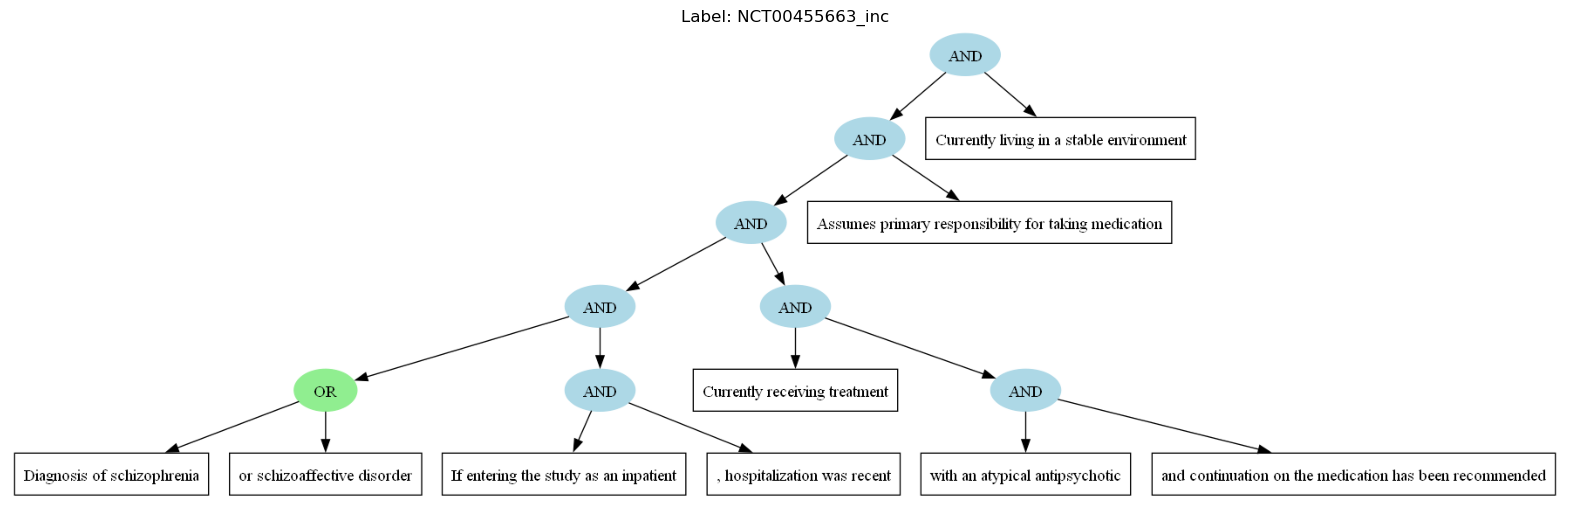

KeyboardInterrupt: 

In [5]:
# check label
for label_file in label_files:
    base_name = label_file.split("_parsed_2.json")[0]

    label_file_path = os.path.join(p2_label_path, label_file)
    with open(label_file_path, 'r', encoding='utf-8') as f:
        label_data = json.load(f)


    label_output_path = os.path.join(picture_path, f"{base_name}_label.png")
    plot_and_save_graph(label_data, f"Label: {base_name}", label_output_path)

In [6]:
# Model vs Label muss überarbeitet werden 
for label_file in label_files:
    base_name = label_file.split("_parsed_2.json")[0]
    
    model = model_name.split("_")[0]
    nshot = model_name.split("_")[1]
    model_file = f"{model}_{base_name}_{nshot}_shot.json"
    print(model_file)
    if model_file in model_files:
        label_file_path = os.path.join(p2_label_path, label_file)
        model_file_path = os.path.join(model_input_path, model_file)
        with open(label_file_path, 'r', encoding='utf-8') as f:
            label_data = json.load(f)

        print("label data: ", label_data)
        with open(model_file_path, 'r', encoding='utf-8') as f:
            model_data = json.load(f)

        label_output_path = os.path.join(picture_path, f"{base_name}_label.png")
        model_output_path = os.path.join(picture_path, f"{base_name}_model.png")

        plot_and_save_graph(label_data, f"Label: {base_name}", label_output_path)
        plot_and_save_graph(model_data, f"Model: {base_name}", model_output_path)

Llama-3-8B-Instruct_NCT00050349_exc_4_shot.json
Llama-3-8B-Instruct_NCT00050349_inc_4_shot.json
Llama-3-8B-Instruct_NCT00061308_exc_4_shot.json
Llama-3-8B-Instruct_NCT00061308_inc_4_shot.json
Llama-3-8B-Instruct_NCT00094861_exc_4_shot.json
Llama-3-8B-Instruct_NCT00094861_inc_4_shot.json
Llama-3-8B-Instruct_NCT00122070_exc_4_shot.json
Llama-3-8B-Instruct_NCT00122070_inc_4_shot.json
Llama-3-8B-Instruct_NCT00182520_exc_4_shot.json
Llama-3-8B-Instruct_NCT00182520_inc_4_shot.json
Llama-3-8B-Instruct_NCT00183885_exc_4_shot.json
Llama-3-8B-Instruct_NCT00183885_inc_4_shot.json
Llama-3-8B-Instruct_NCT00198913_exc_4_shot.json
Llama-3-8B-Instruct_NCT00198913_inc_4_shot.json
Llama-3-8B-Instruct_NCT00235170_exc_4_shot.json
Llama-3-8B-Instruct_NCT00235170_inc_4_shot.json
Llama-3-8B-Instruct_NCT00236340_exc_4_shot.json
Llama-3-8B-Instruct_NCT00236340_inc_4_shot.json
Llama-3-8B-Instruct_NCT00250640_exc_4_shot.json
Llama-3-8B-Instruct_NCT00250640_inc_4_shot.json
Llama-3-8B-Instruct_NCT00279552_exc_4_sh